# Generative Language Models

## Project 3 - Development of a Case Study with Model Evaluation

CRISP-DM: **Phases 1-6**

---

Authors: **António Cruz** (140129), **Erik Daskalyuk** (120062), **Ivan Magalhães** (106586), **Ricardo Kayseller** (95813), **Ricardo Pereira** (120052)

Date: **2025-11-18**

&#160;

# 0. Environment Setup

---

In [2]:
# Install required packages
! pip install -q transformers torch pandas numpy scikit-learn matplotlib seaborn tqdm pyarrow protobuf wordcloud parquet

## 0.1 Libraries Import

In [55]:
from __future__ import annotations
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import re
import html
import json
import pandas as pd
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import statistics

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from scipy.spatial import ConvexHull
from wordcloud import WordCloud

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import warnings

## 0.2 Global Configuration

In [4]:
# Set device type
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
Memory: 25.76 GB


In [5]:
# Models Local Path
MODEL_PATHS = {
    'scibert': './models/scibert_scivocab_uncased',  
    'deberta': './models/microsoft/deberta-v3-base',
    'roberta': './models/roberta-base',
    'specter2': './models/specter2',
    'longformer': './models/longformer-base-4096',
}

# Key Configuration Parameters
CONFIG = {
    # Model selection
    'MODEL_TYPE': 'scibert',

    # Data parameters
    'MIN_SAMPLES_PER_CATEGORY': 100,
    'MAX_SAMPLES_PER_CATEGORY': 500,
    # Set True to concatenate title with abstract
    'USE_TITLE': True,
    
    # Training parameters
    'EPOCHS': 15,
    'BATCH_SIZE': 16,
    'LEARNING_RATE': 2e-5,
    'MAX_LENGTH': 512,
    'WARMUP_STEPS': 500,
    'PATIENCE': 4,
    
    # Advanced features
    'USE_LABEL_SMOOTHING': True,
    'LABEL_SMOOTHING_ALPHA': 0.1,
    'USE_MIXUP': True,
    'MIXUP_ALPHA': 0.2,
    'DROPOUT_RATE': 0.3,
    
    # Hierarchical classification:
    # Set True for 2 stage classification
    'USE_HIERARCHICAL': False,
}

In [6]:
# Select and load model, based on configuration
model_type = CONFIG["MODEL_TYPE"]
model_path = MODEL_PATHS[model_type]
use_local = (model_type == "scibert")

print(f"Loading {model_type} model from: {model_path}")
print(f"Using local files: {use_local}")

Loading scibert model from: ./models/scibert_scivocab_uncased
Using local files: True


In [7]:
# Suppress verbose logs
warnings.filterwarnings('ignore')

In [8]:
# Path to dataset's .parquet file
PARQUET_FILE_PATH = "./data/arxiv_papers/train.parquet"

# Ensure reproducibility
SEED=42

&#160;

# 1. Business Understanding

---

## 1.1 Problem Definition


The volume of academic literature published every day continues to grow across all fields of study. Each new paper introduces a unique contribution—whether a novel solution, a methodological innovation, or a theoretical analysis requiring accurate categorization to be discoverable and useful. Traditionally, papers are classified according to their content, methodology, contribution type, and research domain (e.g., empirical studies, reviews, theoretical work, descriptive or analytical approaches).

However, as publications scale in both volume and interdisciplinarity, manual categorization has become increasingly impractical, inconsistent, and time-consuming. The complexity of modern research means that many papers naturally span multiple categories for instance, mathematical modeling within physics or machine learning applied to social sciences. Traditional single-label or softmax-based classification systems are inadequate for this reality because they force a paper into a single dominant category or enforce normalized probabilities across categories.

In addition to scalability challenges, classification inconsistency among human reviewers poses a significant problem. Different experts may categorize the same paper differently or attribute varying levels of relevance to certain domains. Such subjectivity reduces reliability and introduces bias into bibliographic systems. Our model seeks to address this challenge by producing standardized, repeatable, and objective multi-label classifications, reducing human disagreement and enabling a consistent categorization framework across large-scale repositories.

The increasing complexity and volume of academic literature create a clear need for an automated system capable of providing accurate, multi-label, domain-independent categorization at scale. Such a system must not only identify the primary category of a paper but also assign independent relevance probabilities across multiple fields.

## 1.2 Stakeholders

Researchers and Academics
- Primary users who rely on accurate categorization to quickly find relevant literature.
- Benefit from reduced time spent searching through poorly organized or uncategorized papers.

Librarians and Information Specialists
- Currently responsible for manually classifying and organizing academic publications.
- Gain efficiency through automation and improved consistency in taxonomy management.

Research Institutions and Universities
- Need to maintain organized repositories of academic output.
- Benefit from streamlined workflows, increased discoverability of internal research, and reduced operational costs.

## 1.3 Value Creation

Our solution automates the multi-label classification of academic papers. Unlike traditional softmax-based classifiers, which distribute probabilities across categories so that they sum to 1, our model assigns:

- A separate, independent probability to each category

- No normalization constraint a paper can strongly belong to multiple fields

- Flexible relevance scores that reflect real interdisciplinary relationships

This approach mirrors human judgment more accurately than mutually exclusive classification, while eliminating human inconsistency and subjectivity.

By standardizing and automating classification, the system reduces manual labor, improves accuracy and consistency, and increases the discoverability of relevant research. It also frees researchers and librarians to perform higher-value analytical tasks instead of repetitive sorting activities.

## 1.4 Model Performance and Practical Value

Although our model is not 100% accurate in classifying every academic paper, an expected limitation given the inherent complexity and multidisciplinary nature of the literature, it demonstrates promising performance. It is able to correctly classify more than half of the papers across a wide range of possible categories, which is a strong result compared to both random chance and inconsistent human labeling.

This level of performance already provides significant value through:

- Reliable baseline categorization

- Reduction of human disagreement

- Ability to scale across thousands or millions of documents (with the correct infrastructure)

As the model continues to learn from additional data and refined taxonomies, we expect its accuracy and robustness to further improve, strengthening its role as a core component of modern academic knowledge infrastructure.

# 2. Data Understanding

---

## 2.1 ArXiv Scientific Articles Dataset

Perform an in-depth Data Understanding and Exploratory Data Analysis (EDA) on a large corpus of scientific articles extracted from arXiv (≈2.55M records).
The goal of this stage is to thoroughly examine the characteristics, structure, and quality of the dataset before building any machine learning or language model–based classifier.

Objectives of this Data Understanding stage:

1. Inspect the dataset structure

   - Review columns, datatypes, and the general schema
   - Verify consistency of key fields (title, abstract, subjects, authors)

2. Assess data quality

   - Identify missing, inconsistent, or malformed entries
   - Detect anomalies in abstracts, dates, author lists, and subject labels

3. Explore distributions and content characteristics

   - Distribution of scientific subjects
   - Abstract length statistics and text quality indicators
   - Unique values, duplication analysis, and potential noise sources

4. Establish the suitability of the data for downstream tasks

   - Validate the feasibility of scientific article classification using titles and abstracts
   - Understand challenges such as class imbalance, text variability, and metadata inconsistencies

## 2.2 Load Data

In [9]:
# Path to parquet file
PARQUET_FILE_PATH = "./data/arxiv_papers/train.parquet"

In [10]:
# Load the parquet file from local folder
df = pd.read_parquet(PARQUET_FILE_PATH)
print(f"Loaded {len(df):,} total papers")

Loaded 2,549,619 total papers


In [11]:
# Count total number of rows in the DataFrame
print("Total row count:")
count_total = len(df)
print(count_total)

# Select all rows (entire DataFrame)
print("\nAll rows (first 5 shown):")
print(df.head())

# Count occurrences of each primary_subject value (excluding null values), sorted by count descending
print("\nCount of records by primary_subject (excluding nulls, sorted by count descending):")
result3 = (
    df[df["primary_subject"].notna()]
    .groupby("primary_subject")
    .size()
    .reset_index(name="total")
    .sort_values("total", ascending=False)
)
print(result3)

# Clean distribution of abstract character lengths by bucket
print("\nDistribution of abstract character lengths by bucket:")

# Work only on rows with a non-null abstract
abstracts_not_null = df[df["abstract"].notna()].copy()

# Character length of each abstract
abstracts_not_null["abs_len"] = abstracts_not_null["abstract"].astype(str).str.len()

# Define bins and labels for character length ranges
# [0,1)  -> '0'        (true empties, if any)
# [1,100)-> '1-99'
# [100,200)-> '100-199', etc.
max_len = abstracts_not_null["abs_len"].max()
bins = [0, 1, 100, 200, 400, 800, 1600, 2000, 4096, max_len + 1]
labels = [
    "0",
    "1-99",
    "100-199",
    "200-399",
    "400-799",
    "800-1599",
    "1600-1999",
    "2000-4095",
    "4096+",
]

# Assign each abstract length to a bucket
abstracts_not_null["bucket"] = pd.cut(
    abstracts_not_null["abs_len"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

# Count total per bucket
dist = (
    abstracts_not_null["bucket"]
    .value_counts(dropna=False)
    .sort_index()              # follow label order
    .rename_axis("bucket")
    .reset_index(name="total")
)

# Calculate percentages over all non-null abstracts
total_abstracts = dist["total"].sum()
dist["pct"] = (100.0 * dist["total"] / total_abstracts).round(4)

print(dist)

Total row count:
2549619

All rows (first 5 shown):
    arxiv_id                                              title  \
0  0902.3253  The gravitational wave background from star-ma...   
1  0902.0428  Dynamics of planets in retrograde mean motion ...   
2  0901.3401  Diurnal Thermal Tides in a Non-synchronized Ho...   
3  0901.1570  Intermittent turbulence, noisy fluctuations an...   
4  0901.2048        Falling Transiting Extrasolar Giant Planets   

                                             authors  \
0       [Silvia Toonen, Clovis Hopman, Marc Freitag]   
1              [Julie Gayon, Eric Bois, Hans Scholl]   
2                    [Pin-Gao Gu, Gordon I. Ogilvie]   
3  [Z. Vörös, T. L. Zhang, M. P. Leubner, M. Volw...   
4        [B. Levrard, C. Winisdoerffer, G. Chabrier]   

                                     submission_date  \
0  18 Feb 2009 (<a href="https://arxiv.org/abs/09...   
1                                         3 Feb 2009   
2                                       

In [12]:
print("DataFrame shape (rows, columns):", df.shape)

print("\nColumns:")
print(df.columns.tolist())

try:
    from IPython.display import display
    print("\nFirst 5 rows:")
    display(df.head(5))
except ImportError:
    print("\nFirst 5 rows:")
    print(df.head(5))

DataFrame shape (rows, columns): (2549619, 10)

Columns:
['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path']

First 5 rows:


,arxiv_id,title,authors,submission_date,comments,primary_subject,subjects,doi,abstract,file_path
0,0902.3253,The gravitational wave background from star-ma...,"[Silvia Toonen, Clovis Hopman, Marc Freitag]","18 Feb 2009 (<a href=""https://arxiv.org/abs/09...",Accepted for publication by MNRAS; New appendi...,Earth and Planetary Astrophysics (astro-ph.EP),Earth and Planetary Astrophysics (astro-ph.EP),https://doi.org/10.48550/arXiv.0902.3253,Stars on eccentric orbits around a massive bla...,astro-ph-00.zip/0902.3253.pdf
1,0902.0428,Dynamics of planets in retrograde mean motion ...,"[Julie Gayon, Eric Bois, Hans Scholl]",3 Feb 2009,"15 pages, 3 figures, accepted for publication ...",Earth and Planetary Astrophysics (astro-ph.EP),Earth and Planetary Astrophysics (astro-ph.EP),https://doi.org/10.48550/arXiv.0902.0428,"In a previous paper (Gayon &amp; Bois 2008a), ...",astro-ph-00.zip/0902.0428.pdf
2,0901.3401,Diurnal Thermal Tides in a Non-synchronized Ho...,"[Pin-Gao Gu, Gordon I. Ogilvie]",22 Jan 2009,accepted for publication in MNRAS,Earth and Planetary Astrophysics (astro-ph.EP),Earth and Planetary Astrophysics (astro-ph.EP),https://doi.org/10.48550/arXiv.0901.3401,We perform a linear analysis to investigate th...,astro-ph-00.zip/0901.3401.pdf
3,0901.1570,"Intermittent turbulence, noisy fluctuations an...","[Z. Vörös, T. L. Zhang, M. P. Leubner, M. Volw...",12 Jan 2009,,Earth and Planetary Astrophysics (astro-ph.EP),Earth and Planetary Astrophysics (astro-ph.EP),https://doi.org/10.48550/arXiv.0901.1570,Recent research has shown that distinct physic...,astro-ph-00.zip/0901.1570.pdf
4,0901.2048,Falling Transiting Extrasolar Giant Planets,"[B. Levrard, C. Winisdoerffer, G. Chabrier]",14 Jan 2009,To appear in ApJ Letters,Earth and Planetary Astrophysics (astro-ph.EP),Earth and Planetary Astrophysics (astro-ph.EP),https://doi.org/10.48550/arXiv.0901.2048,We revisit the tidal stability of extrasolar s...,astro-ph-00.zip/0901.2048.pdf


### 2.2.1 Initial Data Load Interpretation

The dataset successfully loaded with a total of **2,549,619 records** and **10 columns**, indicating a large-scale scientific metadata collection suitable for NLP-driven classification tasks.

The first fields inspection confirms the presence of the main elements expected for arXiv articles:

**Table 2.1** - First fields inspection

| Column | Observation |
|--------|-------------|
| `arxiv_id` | Unique identifier present in all previewed rows. |
| `title` | Informative scientific titles, typically long and domain-specific. |
| `authors` | Stored as a stringified list, indicating a need for parsing if used for author-level analysis. |
| `submission_date` | Some values contain embedded HTML markup (e.g., `<a href=...>`), which will require cleaning. |
| `comments` | Heterogeneous notes, not consistently populated. May require filtering or optional use. |
| `primary_subject` / `subjects` | Core labels for classification. Early inspection suggests clean and readable subject tags. |
| `doi` | Contains DOIs for traceability, though likely not complete for all entries. |
| `abstract` | Core textual field for modeling. Appears well populated in the sample. |
| `file_path` | Points to original PDF storage, enabling future full-text extraction if needed. |

Overall, the dataset structure is consistent with expectations for arXiv metadata and appears **well-suited for downstream modeling**—particularly classification tasks based on `title` and/or `abstract`. The next steps will include:

- inspecting missing values and data types,
- assessing class distribution for `primary_subject`,
- exploring abstract length variability to validate text richness for LLM tasks.


## 2.3 Dtypes and Missing Values Analysis

In [13]:
print("=== DataFrame info ===")
df.info()

print("\n=== Missing values (%) per column ===")
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print(missing_pct)

print("\n=== Number of unique values per column (safe) ===")
unique_counts = {}

for col in df.columns:
    try:
        # Standard nunique for hashable types
        unique_counts[col] = df[col].nunique(dropna=True)
    except TypeError:
        # For unhashable / array-like objects (e.g., numpy.ndarray)
        unique_counts[col] = "unhashable/array-like -> needs custom handling"

unique_counts = pd.Series(unique_counts)
print(unique_counts)


=== DataFrame info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2549619 entries, 0 to 2549618
Data columns (total 10 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   arxiv_id         object
 1   title            object
 2   authors          object
 3   submission_date  object
 4   comments         object
 5   primary_subject  object
 6   subjects         object
 7   doi              object
 8   abstract         object
 9   file_path        object
dtypes: object(10)
memory usage: 194.5+ MB

=== Missing values (%) per column ===
arxiv_id           0.0
title              0.0
authors            0.0
submission_date    0.0
comments           0.0
primary_subject    0.0
subjects           0.0
doi                0.0
abstract           0.0
file_path          0.0
dtype: float64

=== Number of unique values per column (safe) ===
arxiv_id                                                  2549619
title                                                     2545799
author

### 2.3.1 Data Types, Missing Values, and Cardinality – Interpretation

The `info()` summary shows that all **10 columns are stored as `object` type**, which is typical for text-heavy datasets but also indicates that:

- Dates (e.g., `submission_date`) are not yet parsed as proper `datetime` objects.
- Structured fields like `authors` and `subjects` are currently represented as generic Python objects or stringified lists and may require custom parsing for deeper analysis.

A key observation is that **there are no missing values reported in any column (0.0% missing)**. While this looks ideal at first glance, it also suggests that:
- Any apparent “absence” of information is likely encoded as empty strings, minimal text, or placeholder content rather than `NaN`.
- Data quality issues, if present, will be more semantic (e.g., noisy text, HTML fragments) than structural (nulls).

Regarding cardinality (number of distinct values):

- `arxiv_id` and `file_path` are **fully unique**, matching the total number of rows – each record corresponds to a unique article and PDF path.
- `doi` is almost fully unique as well (`2549556` unique values vs `2,549,619` rows), which is consistent with each published article being mapped to a specific DOI, with a small fraction possibly missing or duplicated.
- `title` and `abstract` also show **very high uniqueness**, confirming that they can be treated as instance-level descriptors, ideal for text-based classification and retrieval tasks.
- `primary_subject` has **only 148 unique values**, which aligns well with its role as a **categorical label** for a multi-class classification problem.
- `subjects` has **85,221 unique combinations**, which reflects the multidimensional tagging of arXiv papers (multiple subjects per article). It is more complex to work with as a label space and may require simplification (e.g., using only `primary_subject` or deriving higher-level domain groupings).
- The `authors` column is reported as *“unhashable/array-like → needs custom handling”*, confirming that it likely contains list-like structures (arrays or Python lists). This is important for future work on collaboration networks or author-level statistics but is **not immediately suitable** for standard groupby operations without preprocessing.



## 2.4 Category Class Distribution

In [14]:
print("=== primary_subject distribution (absolute counts) ===")
primary_counts = df["primary_subject"].value_counts(dropna=False)
print("Number of distinct primary_subject values:", primary_counts.shape[0])
print(primary_counts.head(20))

print("\n=== primary_subject distribution (relative frequency %) ===")
primary_pct = (primary_counts / len(df) * 100).round(4)
print(primary_pct.head(20))

=== primary_subject distribution (absolute counts) ===
Number of distinct primary_subject values: 148
primary_subject
Computer Vision and Pattern Recognition (cs.CV)         120122
Quantum Physics (quant-ph)                              120051
High Energy Physics - Phenomenology (hep-ph)            116920
Machine Learning (cs.LG)                                106484
High Energy Physics - Theory (hep-th)                    93277
Mesoscale and Nanoscale Physics (cond-mat.mes-hall)      66783
Materials Science (cond-mat.mtrl-sci)                    66516
Computation and Language (cs.CL)                         64648
General Relativity and Quantum Cosmology (gr-qc)         53865
Analysis of PDEs (math.AP)                               52332
Astrophysics of Galaxies (astro-ph.GA)                   51321
Strongly Correlated Electrons (cond-mat.str-el)          50607
Combinatorics (math.CO)                                  48341
Solar and Stellar Astrophysics (astro-ph.SR)             46087


### 2.4.1 Distribution of Primary Subjects - Scientific Domain Imbalance

The `primary_subject` field contains **148 distinct scientific categories**, reflecting the breadth of the arXiv taxonomy. However, the distribution is **highly imbalanced**, with a small set of domains concentrating a large fraction of all papers.

The top categories include:

- **Computer Vision and Pattern Recognition (cs.CV)** – 120,122 papers (~4.71%)
- **Quantum Physics (quant-ph)** – 120,051 (~4.71%)
- **High Energy Physics – Phenomenology (hep-ph)** – 116,920 (~4.59%)
- **Machine Learning (cs.LG)** – 106,484 (~4.18%)
- **High Energy Physics – Theory (hep-th)** – 93,277 (~3.66%)

Together, just these five labels account for more than **one-fifth of the entire dataset**, highlighting a strong concentration in a few research communities such as computer vision, machine learning, quantum physics, and high-energy physics.

Beyond the top group, we see substantial representation of:

- Condensed matter subfields (e.g., *cond-mat.mes-hall*, *cond-mat.mtrl-sci*, *cond-mat.str-el*),
- Core mathematics categories (e.g., *math.AP*, *math.CO*, *math.PR*, *math.AG*),
- Astrophysics subdomains (e.g., *astro-ph.GA*, *astro-ph.SR*, *astro-ph.HE*, *astro-ph.CO*),
- Information theory and related CS-theory areas (e.g., *cs.IT*).

This pattern confirms that:

1. The classification task is a **multi-class problem with a long-tailed label distribution**.
2. Any model trained to predict `primary_subject` must be evaluated with **metrics that are robust to class imbalance**, such as macro-averaged F1, rather than overall accuracy alone.
3. It may be beneficial to:
   - focus on a subset of high-frequency subjects for an initial prototype,
   - or group fine-grained arXiv categories into higher-level super-domains (e.g., “Computer Science”, “Physics”, “Mathematics”) to ease the learning problem and improve interpretability.

From a data understanding perspective, this distribution strongly motivates a careful **design of the label space and evaluation strategy** before training classification models.


In [ ]:
@dataclass
class LabelClusterVisualizer:
	"""
	Utility for visualizing clustering of label texts using a transformer encoder.

	Typical usage:

		viz = LabelClusterVisualizer(model_name="models/longformer-base-4096")
		result = viz.visualize(categories)  # categories: List[str] of primary_subjects

	Allows to inspect:
		- result["coords"]       -> np.ndarray [num_labels, 2]
		- result["cluster_ids"]  -> np.ndarray [num_labels]
		- result["codes"]        -> List[str] (short label codes like 'cs.CV')
		- result["labels"]       -> original full label strings

	It can print a textual summary:
		viz.print_cluster_summary()
	"""

	model_name: str
	max_length: int = 64
	n_clusters: int = 12
	random_state: int = 42
	device: Optional[str] = None  # "cuda", "cpu", or None for auto

	# Internal state (populated after visualize())
	_tokenizer: Any = None
	_model: Any = None
	_last_embeddings: Optional[np.ndarray] = None
	_last_coords: Optional[np.ndarray] = None
	_last_cluster_ids: Optional[np.ndarray] = None
	_last_codes: Optional[List[str]] = None
	_last_labels: Optional[List[str]] = None

	def __post_init__(self) -> None:
		if self.device is None:
			self.device = "cuda" if torch.cuda.is_available() else "cpu"

		self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)
		self._model = AutoModel.from_pretrained(self.model_name)
		self._model.to(self.device)
		self._model.eval()

	def _extract_code(self, subject: str) -> str:
		"""
		Extract a compact code from a full subject string.
		Takes first two letters of each '.' segment.

		Example:
			"Computer Vision and Pattern Recognition (cs.CV)" -> "cs.CV" 
			"Astrophysics of Galaxies (astro-ph.GA)" -> "as.ga"
			"Machine Learning (cs.LG)" -> "cs.lg"
		If no parentheses are found, returns the original string.
		"""
		if "(" in subject and ")" in subject:
			# Extract content in parentheses
			code = subject.split("(")[-1].split(")")[0].strip()
			
			# Split by '.' and take first 2 letters of each segment
			segments = code.split('.')
			shortened_segments = []
			for segment in segments:
				if len(segment) >= 3:
					shortened_segments.append(segment[:3].lower())
				else:
					shortened_segments.append(segment.lower())
			
			return '.'.join(shortened_segments)
		return subject

	def embed_labels(self, labels: List[str]) -> np.ndarray:
		"""
		Encode label texts into embeddings using the underlying model.

		Returns:
			embeddings: np.ndarray of shape [num_labels, hidden_dim]
		"""
		if len(labels) == 0:
			raise ValueError("embed_labels: labels list is empty")

		enc = self._tokenizer(
			labels,
			padding=True,
			truncation=True,
			max_length=self.max_length,
			return_tensors="pt",
		)
		enc = {k: v.to(self.device) for k, v in enc.items()}

		with torch.no_grad():
			out = self._model(**enc)

		hidden = out.last_hidden_state  # [B, L, H]
		# CLS pooling (token 0):
		# For RoBERTa/Longformer-style models, this is common
		embeddings = hidden[:, 0, :].detach().cpu().numpy()
		return embeddings

	def cluster(self, embeddings: np.ndarray) -> np.ndarray:
		"""
		Run k-means clustering on embeddings.

		Returns:
			cluster_ids: np.ndarray of shape [num_labels] with integer cluster id.
		"""
		if embeddings.ndim != 2:
			raise ValueError(f"cluster: expected 2D embeddings, got shape {embeddings.shape}")

		kmeans = KMeans(
			n_clusters=self.n_clusters,
			random_state=self.random_state,
			n_init=10,
		)
		cluster_ids = kmeans.fit_predict(embeddings)
		return cluster_ids

	def project_to_2d(self, embeddings: np.ndarray) -> np.ndarray:
		"""
		Project embeddings to 2D with t-SNE for visualization.

		Returns:
			coords: np.ndarray [num_labels, 2]

		NOTES:
			Perplexity represents the effective number of neighbors each point considers 
			when calculating pairwise similarities in the high-dimensional space.
		
			In the context of t-SNE (t-distributed Stochastic Neighbor Embedding),
			perplexity is a crucial hyperparameter that essentially controls the balance
			between preserving local vs. global structure in the data during dimensionality reduction.
		"""
		if embeddings.ndim != 2:
			raise ValueError(f"project_to_2d: expected 2D embeddings, got shape {embeddings.shape}")

		num_points = embeddings.shape[0]
		# Perplexity must be < num_points
		# A reasonable value must be selected
		perplexity = min(30, max(5, num_points // 5))

		tsne = TSNE(
			n_components=2,
			random_state=self.random_state,
			perplexity=perplexity,
			init="random",
		)
		coords = tsne.fit_transform(embeddings)
		return coords

	def visualize(
		self,
		label_texts: List[str],
		show_codes: bool = True,
		figsize: Tuple[int, int] = (12, 9),
		alpha: float = 0.85,
		fontsize: int = 7,
	) -> Dict[str, Any]:
		"""
		Full pipeline:
			- Compute embeddings for label_texts
			- Cluster them
			- Project to 2D
			- Plot scatter with codes as annotated labels

		Stores results on the instance and returns them as a dict.
		"""
		if len(label_texts) == 0:
			raise ValueError("visualize: label_texts list is empty")

		# Prepare codes (compact labels) for annotation
		label_codes = [self._extract_code(t) for t in label_texts]

		# 1) Embeddings
		embeddings = self.embed_labels(label_texts)

		# 2) Clustering
		cluster_ids = self.cluster(embeddings)

		# 3) 2D projection
		coords = self.project_to_2d(embeddings)

		# 4) Plot
		plt.figure(figsize=figsize)

		plt.xticks(np.arange(-10, 8, 2.5))
		plt.yticks(np.arange(-10, 11, 2.5))
		plt.grid(True, 
					which='major',
					alpha=0.75,
					linestyle='--',
					linewidth=0.3,
					color='gray',
					zorder=-2)

		scatter = plt.scatter(
			coords[:, 0],
			coords[:, 1],
			c=cluster_ids,
			cmap="tab20",
			alpha=alpha,
			s=50  # Add point size for better visibility
		)

		if show_codes:
			for i, code in enumerate(label_codes):
				plt.annotate(
					code,
					xy=(coords[i, 0], coords[i, 1]),           # Point to annotate
					xytext=(5, 5),                              # Offset from point
					textcoords='offset points',                 # Use offset points
					fontsize=fontsize,
					ha='left', va='bottom',
					# bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8),
					arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.7),
					clip_on=True
				)

		unique_clusters = np.unique(cluster_ids)
		for cid in unique_clusters:
			mask = cluster_ids == cid
			cluster_points = coords[mask]

			if len(cluster_points) < 3:
				continue  # Skip small clusters (can't form hull)

			try:
				hull = ConvexHull(cluster_points)
				# Get vertices of convex hull
				hull_points = cluster_points[hull.vertices]

				# Create polygon patch
				poly = patches.Polygon(hull_points, 
										alpha=0.1,  # very faint
										facecolor=plt.cm.tab20(cid), 
										edgecolor=None)
				plt.gca().add_patch(poly)
			except:
				# Fallback: draw circle around centroid
				centroid = np.mean(cluster_points, axis=0)
				circle = plt.Circle(centroid, 
									radius=np.std(np.linalg.norm(cluster_points - centroid, axis=1)) * 1.5,
									alpha=0.1,
									facecolor=plt.cm.tab20(cid),
									edgecolor=None)
				plt.gca().add_patch(circle)			

		plt.title("Clustering of Research Topic Labels by Semantic Similarity")
		plt.xlabel("t-SNE dim 1")
		plt.ylabel("t-SNE dim 2")

		# Ticks font size
		plt.tick_params(axis='both', which='major', labelsize=8)

		plt.grid(True, alpha=0.6)
		plt.tight_layout()
		plt.show()

		# Save state
		self._last_embeddings = embeddings
		self._last_coords = coords
		self._last_cluster_ids = cluster_ids
		self._last_codes = label_codes
		self._last_labels = list(label_texts)

		return {
			"embeddings": embeddings,
			"coords": coords,
			"cluster_ids": cluster_ids,
			"codes": label_codes,
			"labels": list(label_texts),
		}

	def get_cluster_summary(self) -> Dict[int, List[Tuple[str, str]]]:
		"""
		Return a mapping: cluster_id -> list of (code, full_label).

		Requires that visualize() has been called at least once.
		"""
		if (
			self._last_cluster_ids is None
			or self._last_codes is None
			or self._last_labels is None
		):
			raise RuntimeError("get_cluster_summary: call visualize() first")

		clusters: Dict[int, List[Tuple[str, str]]] = {}
		for cid, code, label in zip(
			self._last_cluster_ids, self._last_codes, self._last_labels
		):
			clusters.setdefault(int(cid), []).append((code, label))
		return clusters

	def print_cluster_summary(self) -> None:
		"""
		Print a human-readable summary of clusters:
		"""
		clusters = self.get_cluster_summary()
		# Global counter across all clusters
		global_idx = 1
		
		for cid in sorted(clusters.keys()):
			print(f"\n=== Cluster {cid} ===")
			for code, full in clusters[cid]:
				print(f"  {global_idx}. {code:10s}  {full}")
				global_idx += 1

148 categories


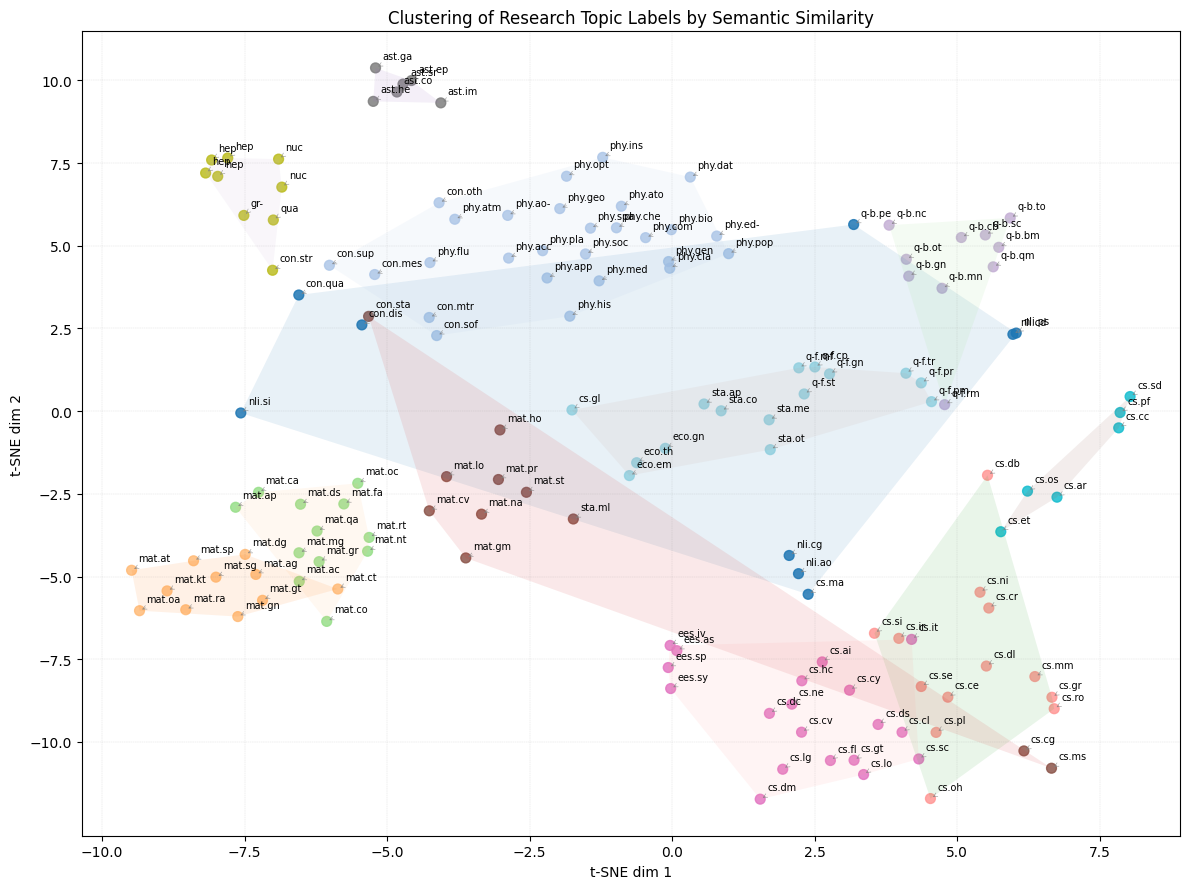


=== Cluster 0 ===
  1. nli.ao      Adaptation and Self-Organizing Systems (nlin.AO)
  2. nli.cg      Cellular Automata and Lattice Gases (nlin.CG)
  3. nli.cd      Chaotic Dynamics (nlin.CD)
  4. con.dis     Disordered Systems and Neural Networks (cond-mat.dis-nn)
  5. nli.si      Exactly Solvable and Integrable Systems (nlin.SI)
  6. cs.ma       Multiagent Systems (cs.MA)
  7. nli.ps      Pattern Formation and Solitons (nlin.PS)
  8. q-b.pe      Populations and Evolution (q-bio.PE)
  9. con.qua     Quantum Gases (cond-mat.quant-gas)

=== Cluster 1 ===
  10. phy.acc     Accelerator Physics (physics.acc-ph)
  11. phy.app     Applied Physics (physics.app-ph)
  12. phy.ao-     Atmospheric and Oceanic Physics (physics.ao-ph)
  13. phy.ato     Atomic Physics (physics.atom-ph)
  14. phy.atm     Atomic and Molecular Clusters (physics.atm-clus)
  15. phy.bio     Biological Physics (physics.bio-ph)
  16. phy.che     Chemical Physics (physics.chem-ph)
  17. phy.cla     Classical Physics (physic

In [61]:
# Build the categories list
categories = sorted(df["primary_subject"].dropna().unique().tolist())
print(len(categories), "categories")  # should be 148

# Create the visualizer
viz = LabelClusterVisualizer(
    model_name=model_path,
    n_clusters=12,
    max_length=64,
)

# Run the visualization
result = viz.visualize(categories)

# Print a text summary of each cluster
viz.print_cluster_summary()

## 2.5 Abstract Length Analysis

In [ ]:
# Compute abstract length in characters
df["abstract_char_len"] = df["abstract"].str.len()

print("=== Abstract length (characters) - descriptive statistics ===")
print(df["abstract_char_len"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Define buckets similar to earlier manual inspection
bins = [-1, 0, 99, 199, 399, 799, 1599, 1999, 4095, 10_000_000]
labels = [
    "0",
    "1-99",
    "100-199",
    "200-399",
    "400-799",
    "800-1599",
    "1600-1999",
    "2000-4095",
    "4096+",
]

df["abstract_char_bucket"] = pd.cut(
    df["abstract_char_len"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True,
)

print("\n=== Abstract length buckets - counts and percentages ===")
bucket_counts = df["abstract_char_bucket"].value_counts().sort_index()
bucket_pct = (bucket_counts / len(df) * 100).round(4)

bucket_table = pd.DataFrame({
    "bucket": bucket_counts.index,
    "total": bucket_counts.values,
    "pct": bucket_pct.values,
})

print(bucket_table)


### 2.5.1 Abstract Length - Informational Richness for NLP

The `abstract_char_len` statistics confirm that the dataset provides **substantial textual content** for each paper:

- Median length ≈ **956 characters** and mean ≈ **983 characters**, with a standard deviation of ≈ **436**.
- The central 50% of abstracts lie between **644** (25th percentile) and **1,297** characters (75th percentile).
- Very short abstracts are rare: the 1st percentile is already at **167** characters.
- The maximum length reaches **6,554 characters**, but such extremely long abstracts are exceptional.

The bucketed distribution further clarifies the picture:

**Table 2.2** - Dataset bucket distribution

| Bucket       | Share of dataset |
|-------------|------------------|
| 400–799     | 28.71%           |
| 800–1,599   | 52.52%           |
| 1,600–1,999 | 9.89%            |
| < 200       | ~1.61% (combined) |
| ≥ 2,000     | ~0.13%           |

This indicates that:

1. **Over 80%** of the abstracts fall in the range **400–1,600 characters**, which aligns well with typical scientific abstracts (roughly 150–300 words).
2. **Extremely short abstracts (< 200 characters)** are rare and may represent edge cases, such as minimal descriptions, incomplete records, or noisy entries. They can be flagged for potential exclusion or special handling in robustness analyses.
3. **Very long abstracts (≥ 2,000 characters)** are also extremely rare and unlikely to dominate model behavior, though they may slightly increase computational cost.

Overall, the distribution strongly supports the use of `abstract` as a **primary textual feature** for downstream NLP and LLM-based classification: the majority of records provide sufficiently detailed, informative text without being excessively long for modern language models.


## 2.6 Inspect and Clean `submission_date`

In [ ]:
print("=== Examples of raw `submission_date` values ===")
print(df["submission_date"].head(10).tolist())

# Check how many rows contain HTML anchor tags
mask_html = df["submission_date"].str.contains("<a ", regex=False)
num_html = mask_html.sum()
print(f"\nNumber of rows with HTML in `submission_date`: {num_html}")
print(f"Percentage of rows with HTML: {num_html / len(df) * 100:.4f}%")

print("\n=== Sample rows with HTML in `submission_date` ===")
print(df.loc[mask_html, "submission_date"].head(5).tolist())

print("\n=== Sample rows without HTML in `submission_date` ===")
print(df.loc[~mask_html, "submission_date"].head(5).tolist())

# Function to extract the leading date part (before any HTML tag or parenthesis)
def extract_date_only(raw):
    if not isinstance(raw, str):
        return pd.NA
    # Remove HTML tags if present
    cleaned = re.sub(r"<.*?>", "", raw)
    # Keep only text before the first "(" if present
    cleaned = cleaned.split("(")[0].strip()
    return cleaned

# Create a new column with cleaned date string
df["submission_date_clean"] = df["submission_date"].apply(extract_date_only)

print("\n=== Examples of cleaned dates ===")
print(df[["submission_date", "submission_date_clean"]].head(10))


### 2.6.1 Submission Date – HTML Noise and Normalization

The raw `submission_date` field shows two distinct formats:

- **Clean dates**, such as:  
  `3 Feb 2009`, `22 Jan 2009`, `12 Jan 2009`
- **Dates with embedded HTML and revision metadata**, for example:  
  `18 Feb 2009 (<a href="https://arxiv.org/abs/0902.3253v1">v1</a>), last revised 18 Jun 2009 (this version, v2)`

Approximately **37.53% of all records** contain HTML anchor tags (`<a ...>`) inside `submission_date`, which means the field mixes:
- the initial submission date,
- version links,
- and “last revised” information.

For most modeling tasks, especially classification, we only need a **single reference submission date** per paper. The `submission_date_clean` field addresses this by:

1. Stripping out any HTML content using a regular expression,
2. Keeping only the leading date portion before any parentheses.

Examples confirm that:

- `18 Feb 2009 (<a href=...>...)` → `18 Feb 2009`  
- `30 Jan 2009 (<a href=...>...)` → `30 Jan 2009`  
- Already clean dates (e.g. `3 Feb 2009`) remain unchanged.

This normalized string column (`submission_date_clean`) is now suitable for conversion into a proper `datetime` type, enabling temporal analyses such as:
- yearly submission trends,
- time-based stratification,
- or temporal drift analysis in subject distribution.


## 2.7 Datetime Convert and Year Distribution's Inspection

In [ ]:
# Convert cleaned date string to pandas datetime
df["submission_datetime"] = pd.to_datetime(
    df["submission_date_clean"],
    format="%d %b %Y",
    errors="coerce"
)

print("=== Submission datetime conversion ===")
num_nat = df["submission_datetime"].isna().sum()
print(f"Total rows: {len(df)}")
print(f"Rows with NaT (failed date parse): {num_nat} ({num_nat / len(df) * 100:.4f}%)")

print("\n=== Min and max submission dates (excluding NaT) ===")
print("Min:", df["submission_datetime"].min())
print("Max:", df["submission_datetime"].max())

# Extract year
df["submission_year"] = df["submission_datetime"].dt.year

print("\n=== Submission year distribution (top 20 years) ===")
year_counts = df["submission_year"].value_counts().sort_index()
print(year_counts.head(20))

print("\n=== Submission year distribution (last 20 years) ===")
print(year_counts.tail(20))


### 2.7.1 Temporal Coverage - Evolution of Scientific Submissions

After cleaning the `submission_date` field and converting `submission_date_clean` into a proper `datetime` object (`submission_datetime`), all records were successfully parsed:

- **0 rows** failed the date conversion (0.00% NaT).
- The temporal range spans from **1989-11-17** to **2025-09-25**, covering more than three decades of scientific activity.

The yearly submission counts reveal a clear long-term growth trend:

- Early years (1989–1992) show very low volume (from 1 to a few thousand papers per year), reflecting the initial stages of arXiv as a preprint server.
- From the mid-1990s onwards, there is a consistent increase in yearly submissions, with steady growth across the 2000s.
- The 2010s mark a strong expansion phase, with counts surpassing **100,000 submissions per year** around the mid-decade.
- Recent years exhibit peak activity:
  - **2018–2019** already exceed 130k–140k submissions,
  - **2020–2022** surpass **160k–170k**,
  - **2023** reaches **189,381** submissions,
  - **2024** peaks at **212,376** submissions,
  - **2025** (partial year) already accumulates **169,873** submissions up to late September.

This pattern confirms that:

1. The dataset is **dominated by recent submissions**, which is expected given the increasing popularity of arXiv across many disciplines (e.g., machine learning, computer vision, condensed matter, astrophysics).
2. Any modeling effort that samples uniformly across the full dataset will naturally emphasize **modern scientific language and topics**, especially from the last decade.
3. If desired, one could:
   - restrict experiments to a specific time window (e.g., 2010 onwards),
   - or explicitly study **temporal drift** in subject distributions and language usage over time.

From a data understanding perspective, the temporal structure is clean, well-covered, and aligns with the known expansion of arXiv as a central platform for scientific dissemination.


### 2.7.2 Cumulative Coverage of primary_subject

In [ ]:
# Absolute counts
primary_counts = df["primary_subject"].value_counts()

# Distribution table
primary_dist = (
    primary_counts
    .to_frame(name="count")
    .reset_index()
    .rename(columns={"index": "primary_subject"})
)

primary_dist["pct"] = (primary_dist["count"] / len(df) * 100)
primary_dist["cum_pct"] = primary_dist["pct"].cumsum()

print("=== Top 30 primary_subject labels with cumulative coverage ===")
display(primary_dist.head(30))

print("\nTotal number of distinct primary_subject labels:", primary_dist.shape[0])
print(f"Cumulative coverage of top 10 labels: {primary_dist.loc[9, 'cum_pct']:.2f}%")
print(f"Cumulative coverage of top 20 labels: {primary_dist.loc[19, 'cum_pct']:.2f}%")
print(f"Cumulative coverage of top 50 labels: {primary_dist.loc[49, 'cum_pct']:.2f}%")

# --------- Bar chart (Top 20) ---------
top_n = 20
top_labels = primary_dist.head(top_n)

plt.figure(figsize=(12, 6))
plt.barh(top_labels["primary_subject"], top_labels["count"])
plt.gca().invert_yaxis()  # Highest first
plt.title(f"Top {top_n} Primary Subjects by Paper Count")
plt.xlabel("Number of Papers")
plt.ylabel("Primary Subject")
plt.tight_layout()
plt.show()


**Figure 2.1** - Top 10 Primary Subjects by Paper Count

### 2.7.3 Class Concentration - Top-k Primary Subjects

The analysis of `primary_subject` frequencies confirms a **strongly imbalanced label space**. Among the 148 distinct categories, only a small subset concentrates a large proportion of all papers.

From the cumulative distribution:

- The **top 10** subjects already cover **≈33.8%** of all records.
- The **top 20** subjects cover **≈51.0%** of the dataset.
- The **top 50** subjects cover **≈78.7%** of all papers.

The horizontal bar chart of the **Top 20 primary subjects** highlights this pattern visually: a handful of domains dominate the corpus, notably:

- Computer Vision and Pattern Recognition (cs.CV),
- Quantum Physics (quant-ph),
- High Energy Physics – Phenomenology (hep-ph),
- Machine Learning (cs.LG),
- High Energy Physics – Theory (hep-th),
- Condensed Matter subfields,
- Core mathematics categories (e.g., PDEs, combinatorics, probability),
- Astrophysics subdomains,
- Information Theory and related areas.

This has several implications for downstream modeling:

1. The classification problem is **multi-class with a long tail**: many labels appear rarely and will be hard to model reliably with standard supervised approaches.
2. Evaluation using **only accuracy would be misleading**, since a model could perform well on dominant classes while ignoring minority ones. Metrics such as **macro-F1** and per-class analysis are more appropriate.
3. For a practical LLM-based case study, it may be beneficial to:
   - restrict the problem to the **Top-K most frequent labels** (e.g., Top 20 or Top 30), achieving a balance between coverage and tractability, or
   - group fine-grained arXiv categories into a smaller set of **broader scientific domains**, simplifying both training and interpretation.

This distribution strongly motivates a **careful design of the label space** before training or evaluating any classification model on this dataset.


### 2.7.4 Compare primary_subject vs subjects

In [ ]:
# Check how often subjects exactly matches primary_subject
same_mask = df["subjects"] == df["primary_subject"]
same_count = same_mask.sum()
total_rows = len(df)

print("subjects vs primary_subject equality")
print(f"Total rows: {total_rows}")
print(f"Rows where subjects = primary_subject: {same_count} "
      f"({same_count / total_rows * 100:.2f}%)")
print(f"Rows where subjects != primary_subject: {total_rows - same_count} "
      f"({(total_rows - same_count) / total_rows * 100:.2f}%)")

# Show some examples where they differ
print("\n Sample rows where subjects != primary_subject")
diff_examples = df.loc[~same_mask, ["primary_subject", "subjects"]].head(10)
print(diff_examples.to_string(index=False))


### 2.7.5 Primary Subject vs. Full Subject Tagging

The comparison between `primary_subject` and `subjects` reveals that arXiv uses a **hybrid labeling scheme**:

- In **54.49%** of the records, `subjects` is **identical** to `primary_subject`.  
  → In these cases, the paper is effectively associated with a **single subject label**.
- In **45.51%** of the records, `subjects` **differs** from `primary_subject`.  
  → Here, the article is tagged with **multiple subjects**, with `primary_subject` acting as the main category and `subjects` providing additional cross-disciplinary labels.

Examples where they differ show patterns such as:

- A primary label in *Earth and Planetary Astrophysics (astro-ph.EP)* combined with secondary tags like:
  - *Solar and Stellar Astrophysics (astro-ph.SR)*,
  - *Astrophysics of Galaxies (astro-ph.GA)*,
  - *Geophysics (physics.geo-ph)*,
  - *Biological Physics (physics.bio-ph)*,
  - *Populations and Evolution (q-bio.PE)*,
  - *Instrumentation and Methods for Astrophysics (astro-ph.IM)*.

This confirms that:

1. `primary_subject` is a **single-label categorical target** suitable for standard multi-class classification.
2. `subjects` encodes a **richer, multi-label structure**, which could support more advanced tasks such as:
   - multi-label classification,
   - interdisciplinarity analysis,
   - or recommendation systems based on overlapping subject tags.
3. For an initial, well-scoped classification study, it is reasonable to **focus on `primary_subject` as the main label**, while keeping `subjects` as an optional extension for future experiments in multi-label modeling.

Understanding this distinction is crucial to clarifying the target definition and avoiding confusion between single-label and multi-label problem formulations.


### 2.7.6 Number of Subject Tags per Paper

The `num_subject_tags` feature quantifies how many subject labels each paper receives in the `subjects` field.

Key descriptive statistics:

- Mean ≈ **1.65** tags per paper
- Median = **1** tag
- 75th percentile = **2** tags
- Maximum = **11** tags

The discrete distribution shows:

- **1 tag**: 1,389,182 papers (**54.49%**)
- **2 tags**: 785,941 papers (**30.83%**)
- **3 tags**: 280,778 papers (**11.01%**)
- **4 or more tags**: 93,718 papers (**3.68%**)

This confirms that:

1. Most papers are **single-labelled** in practice, with just over half having only one subject tag.
2. A substantial fraction (~31%) has **two subject tags**, reflecting moderate interdisciplinarity.
3. Only a small minority of papers has **three or more** tags, and extreme cases with ≥ 5 tags are rare.

From a modeling perspective, this supports the choice of `primary_subject` as a **single-label target** for the core classification task, while `subjects` can be used later to explore **multi-label extensions** or to analyze cross-disciplinary patterns in the corpus.


In [ ]:
def count_subject_tags(raw):
    if not isinstance(raw, str):
        return 0
    # Split on semicolon and strip whitespace
    parts = [p.strip() for p in raw.split(";") if p.strip() != ""]
    return len(parts)

# Create a new column with the number of subject tags
df["num_subject_tags"] = df["subjects"].apply(count_subject_tags)

print("Descriptive statistics for num_subject_tags ===")
print(df["num_subject_tags"].describe())

print("\n=== Value counts for num_subject_tags ===")
print(df["num_subject_tags"].value_counts().sort_index())

# Aggregated view: 1, 2, 3, 4+
print("\n Aggregated distribution (1, 2, 3, 4+) ===")
agg_counts = {
    "1": (df["num_subject_tags"] == 1).sum(),
    "2": (df["num_subject_tags"] == 2).sum(),
    "3": (df["num_subject_tags"] == 3).sum(),
    "4+": (df["num_subject_tags"] >= 4).sum(),
}
agg_counts = pd.Series(agg_counts)
print(agg_counts)
print("\nPercentages (%):")
print((agg_counts / len(df) * 100).round(2))

In [ ]:
# Rebuild aggregated counts (in case the notebook was restarted)
agg_counts = {
    "1": (df["num_subject_tags"] == 1).sum(),
    "2": (df["num_subject_tags"] == 2).sum(),
    "3": (df["num_subject_tags"] == 3).sum(),
    "4+": (df["num_subject_tags"] >= 4).sum(),
}
agg_counts = pd.Series(agg_counts)

# Identify the category with the maximum value
max_key = agg_counts.idxmax()

colors = []
for k in agg_counts.index:
    if k == max_key:
        colors.append("orange")
    else:
        colors.append("tab:blue")

plt.figure(figsize=(6, 4))
plt.bar(agg_counts.index.astype(str), agg_counts.values, color=colors)
plt.title("Number of Subject Tags per Paper (Aggregated)")
plt.xlabel("Number of Subject Tags")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

**Figure 2.2** - Number of Subject Tags per Paper (Aggregated)

### 2.7.8 Number of Authors Per Paper

In [ ]:
# Quick sanity check on raw types
print("Example values and types from `authors`")
for i in range(3):
    print(i, type(df["authors"].iloc[i]), df["authors"].iloc[i])

def count_authors(raw):
    # Case 1: already a list/tuple/np.ndarray
    if isinstance(raw, (list, tuple, np.ndarray)):
        return len(raw)
    
    # Case 2: missing or empty
    if raw is None:
        return 0
    
    # Case 3: string with some structure
    s = str(raw).strip()
    if s == "":
        return 0
    
    # Try to split by comma (e.g., "A, B, C") or by semicolon as fallback
    if "," in s:
        parts = [p.strip() for p in s.split(",") if p.strip() != ""]
        return len(parts) if parts else 0
    if ";" in s:
        parts = [p.strip() for p in s.split(";") if p.strip() != ""]
        return len(parts) if parts else 0
    
    # Otherwise, treat as a single author
    return 1

df["num_authors"] = df["authors"].apply(count_authors)

print("\nDescriptive statistics for num_authors")
print(df["num_authors"].describe())

print("\nValue counts for num_authors (first 15)")
print(df["num_authors"].value_counts().sort_index().head(15))

print("\nAggregated distribution of authors per paper (1, 2, 3, 4+)")
agg_auth = {
    "1": (df["num_authors"] == 1).sum(),
    "2": (df["num_authors"] == 2).sum(),
    "3": (df["num_authors"] == 3).sum(),
    "4+": (df["num_authors"] >= 4).sum(),
}
agg_auth = pd.Series(agg_auth)
print(agg_auth)

print("\nPercentages (%)")
print((agg_auth / len(df) * 100).round(2))

# Bar chart for aggregated distribution
# Cell 10b - Bar chart for num_authors aggregated (largest bar in orange)

import matplotlib.pyplot as plt
import pandas as pd

agg_auth = {
    "1": (df["num_authors"] == 1).sum(),
    "2": (df["num_authors"] == 2).sum(),
    "3": (df["num_authors"] == 3).sum(),
    "4+": (df["num_authors"] >= 4).sum(),
}
agg_auth = pd.Series(agg_auth)

max_key = agg_auth.idxmax()
colors = ["orange" if k == max_key else "tab:blue" for k in agg_auth.index]

plt.figure(figsize=(6, 4))
plt.bar(agg_auth.index.astype(str), agg_auth.values, color=colors)
plt.title("Number of Authors per Paper (Aggregated)")
plt.xlabel("Number of Authors")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

**Figure 2.3** - Number of Authors per Paper

### 2.7.9 Number of Authors per Paper

The `num_authors` feature captures the size of the author team for each article. The first rows confirm that `authors` is stored as an array-like object, and the counting function now correctly handles those structures.

Key statistics:

- Mean ≈ **4.71** authors per paper  
- Median = **3** authors  
- 25th percentile = **2** authors  
- 75th percentile = **4** authors  
- Maximum = **3,301** authors (extreme large-collaboration papers, typical in high-energy physics and similar fields)

The discrete counts for small team sizes are:

- 1 author: **469,799** papers (**18.43%**)
- 2 authors: **611,577** papers (**23.99%**)
- 3 authors: **526,695** papers (**20.66%**)
- 4 or more authors: **941,545** papers (**36.93%**)

This indicates that:

1. Single-author papers are relatively common but not dominant.
2. The majority of the corpus consists of **small to medium-sized collaborations (2–4 authors)**.
3. A substantial fraction (~37%) involves **larger teams (4+ authors)**, reflecting big collaborations that are typical in certain scientific domains.

From a modeling perspective, the number of authors is **not directly needed** for text classification but can be used for:
- descriptive statistics about collaboration patterns across subjects,
- potential correlation analyses between team size and subject area,
- or as an optional metadata feature in extended models.


### 2.7.10 Sample titles and abstracts by primary_subject

In [ ]:
# Choose a few representative subjects
sample_subjects = [
    "Computer Vision and Pattern Recognition (cs.CV)",
    "Machine Learning (cs.LG)",
    "Quantum Physics (quant-ph)",
    "High Energy Physics - Phenomenology (hep-ph)",
]

for subj in sample_subjects:
    print("\n" + "#" * 80)
    print(f"Primary subject: {subj}")
    print("#" * 80)
    
    subset = df[df["primary_subject"] == subj].sample(3, random_state=42)
    
    for idx, row in subset.iterrows():
        print(f"\narxiv_id: {row['arxiv_id']}")
        print(f"Title   : {row['title']}")
        # Show only the first 400 characters of the abstract for readability
        abstract_snippet = row["abstract"][:400].replace("\n", " ")
        print(f"Abstract: {abstract_snippet}...")


### 2.7.11 Qualitative Look at Titles and Abstracts Across Subjects

The sampled titles and abstracts illustrate clear stylistic and lexical differences across `primary_subject` categories:

- **Computer Vision and Pattern Recognition (cs.CV)**  
  The language is highly technical but application-driven, focusing on concrete tasks such as image inpainting, data efficiency, and text-to-video generation. Abstracts frequently reference:
  - deep learning architectures (CNNs, transformers, diffusion models),
  - practical challenges (data requirements, visual quality, real-time constraints),
  - and benchmark-style evaluation.

- **Machine Learning (cs.LG)**  
  Abstracts tend to emphasize:
  - general-purpose learning frameworks (meta-RL, actor-critic, world models),
  - theoretical or algorithmic contributions (off-policy learning, constrained inference),
  - and broad applicability across tasks or hardware platforms.
  The style is a mix of theoretical and systems-oriented writing, often highlighting scalability and generalization.

- **Quantum Physics (quant-ph)**  
  Here the language shifts toward:
  - highly specialized physical concepts (holonomy, exceptional points, spectral gaps, entangled photons),
  - mathematical formalisms (Riemann surfaces, renormalization methods),
  - and experimental setups (Hong–Ou–Mandel interferometers).
  Abstracts are dense, concept-heavy, and less focused on “datasets” or “benchmarks”, reflecting a more traditional theoretical physics style.

- **High Energy Physics – Phenomenology (hep-ph)**  
  Abstracts are strongly domain-specific, referring to:
  - supersymmetric inflation, heavy-quark expansions, beauty hadron lifetimes,
  - particle production cross sections and collider processes.
  The writing is technical, formula-rich (often including LaTeX notation), and closely aligned with phenomenological modeling and experimental observables.

These qualitative differences support the idea that `title` and `abstract` contain enough **semantic signal** for a model to distinguish between scientific areas. At the same time, they highlight the challenge for any classifier (including LLMs) to handle very heterogeneous writing styles, from application-oriented ML papers to mathematically dense quantum and high-energy physics articles.


### 2.7.12 Title and abstract word length analysis

In [ ]:
def count_words(text):
    if not isinstance(text, str):
        return 0
    # Split on whitespace and filter out empty tokens
    tokens = [t for t in text.strip().split() if t != ""]
    return len(tokens)

# Create new columns
df["title_word_len"] = df["title"].apply(count_words)
df["abstract_word_len"] = df["abstract"].apply(count_words)

print("Descriptive statistics for title_word_len")
print(df["title_word_len"].describe())

print("\nDescriptive statistics for abstract_word_len")
print(df["abstract_word_len"].describe())

# Histogram for title word length
plt.figure(figsize=(6, 4))
# Clip to avoid extremely long titles dominating the axis
title_lengths = np.clip(df["title_word_len"], 0, 40)
plt.hist(title_lengths, bins=40)
plt.title("Title Word Length Distribution (clipped at 40 words)")
plt.xlabel("Number of Words in Title")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

**Figure 2.4** - Title Word Length Distribution

In [ ]:
# Histogram for abstract word length
plt.figure(figsize=(6, 4))
abstract_lengths = np.clip(df["abstract_word_len"], 0, 600)
plt.hist(abstract_lengths, bins=60)
plt.title("Abstract Word Length Distribution (clipped at 600 words)")
plt.xlabel("Number of Words in Abstract")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

**Figure 2.5** - Abstract Word Length Distribution

Title Word Length Distribution:

- The distribution is right-skewed, concentrated mainly between 6 and 14 words.

- Median title length = 9 words, mean ≈ 9.79 words.

- Titles longer than 20 words are rare, and extremely short titles (below 3 words) are also uncommon.

- This suggests typical scientific titles in arXiv are concise, descriptive, and optimized for searchability.

Abstract Word Length Distribution:

- Abstracts show a wider spread, centered approximately between 90 and 200 words.

- Median abstract length = 139 words, mean ≈ 143 words.

- Few cases exceed 300+ words, indicating informal adherence to typical journal/conference limits.

- Most abstracts appear sufficiently long to convey motivation, method, and contribution without excessive verbosity.

These characteristics are highly relevant for downstream text modeling, token budgeting, embedding cost estimation, and classification modeling, especially when working with LLMs that have input size constraints.

### 2.7.13 Plots With Highlighted Peak Frequency Bins

In [ ]:
# ---- Title length: compute histogram on clipped values ----
title_lengths = np.clip(df["title_word_len"], 0, 40)
counts_title, bins_title = np.histogram(title_lengths, bins=40)
peak_index_title = np.argmax(counts_title)

colors_title = []
for i in range(len(counts_title)):
    if i == peak_index_title:
        colors_title.append("orange")   # highlight most common bin
    else:
        colors_title.append("tab:blue")

plt.figure(figsize=(8, 4))
plt.bar(bins_title[:-1], counts_title, width=np.diff(bins_title),
        align="edge", color=colors_title)
plt.title("Title Word Length Distribution (highlighting most common bin)")
plt.xlabel("Number of Words in Title")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

# ---- Abstract length: compute histogram on clipped values ----
abstract_lengths = np.clip(df["abstract_word_len"], 0, 600)
counts_abs, bins_abs = np.histogram(abstract_lengths, bins=50)
peak_index_abs = np.argmax(counts_abs)

colors_abs = []
for i in range(len(counts_abs)):
    if i == peak_index_abs:
        colors_abs.append("green")      # highlight most common bin
    else:
        colors_abs.append("tab:blue")

plt.figure(figsize=(8, 4))
plt.bar(bins_abs[:-1], counts_abs, width=np.diff(bins_abs),
        align="edge", color=colors_abs)
plt.title("Abstract Word Length Distribution (highlighting most common bin)")
plt.xlabel("Number of Words in Abstract")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()


### 2.7.14 Title and abstract length distributions (with highlighted peak bins)

The first histogram shows the distribution of **title length in words**, with the most frequent bin highlighted in orange.  
Most titles cluster tightly around **9–10 words**, confirming that arXiv titles are generally short, dense and highly informative. Very short titles (< 4 words) and very long ones (> 20 words) are rare, which suggests a fairly standardized “style” across scientific fields.

The second histogram shows the **abstract length in words**, with the most frequent bin highlighted in green.  
The peak lies around **140–160 words**, and the bulk of abstracts fall roughly between **100 and 200 words**. Longer abstracts (> 300 words) are uncommon, and extremely short abstracts are also rare. This indicates that abstracts typically provide a reasonably rich description (motivation, method, results) while still remaining within the usual constraints of scientific publishing.

For the classification task, these distributions imply that:
- Titles provide **compact, high-signal context** (≈10 tokens), useful as an auxiliary feature.
- Abstracts are **consistently long enough** to support robust text-based models, but still short enough to fit comfortably within standard LLM context windows.


### 2.7.15 Per-subject profile: mean title length, abstract length, num_authors (Top 20)

In [ ]:
# Ensure required columns exist
required_cols = ["title_word_len", "abstract_word_len", "num_authors"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns. Please compute them first: {missing_cols}")

# Top 20 primary subjects by paper count
primary_counts = df["primary_subject"].value_counts()
top20_subjects = primary_counts.head(20).index.tolist()

# Aggregated metrics
top20_df = (
    df[df["primary_subject"].isin(top20_subjects)]
    .groupby("primary_subject")
    .agg(
        paper_count=("arxiv_id", "count"),
        mean_title_words=("title_word_len", "mean"),
        mean_abstract_words=("abstract_word_len", "mean"),
        mean_num_authors=("num_authors", "mean"),
    )
    .reset_index()
)

# Sort by number of papers
top20_df = top20_df.sort_values(by="paper_count", ascending=False)

print("=== Per-subject profile for Top 20 primary_subjects ===")
print(top20_df)

# Horizontal bar chart for mean abstract length
plt.figure(figsize=(10, 6))
plt.barh(top20_df["primary_subject"], top20_df["mean_abstract_words"])
plt.gca().invert_yaxis()
plt.xlabel("Mean Number of Words in Abstract")
plt.ylabel("Primary Subject")
plt.title("Mean Abstract Length (words) by Primary Subject – Top 20")
plt.tight_layout()
plt.show()


### 2.7.16 Subject-Level Profile

For the 20 most frequent `primary_subject` categories, we computed the mean title length, abstract length and number of authors per paper.

Several clear patterns emerge:

- **Computer Vision (cs.CV) and Machine Learning (cs.LG)**  
  - Long abstracts on average (≈178 and ≈172 words).  
  - Moderate title length (≈9–10 words).  
  - Relatively large author teams (≈4–5 authors per paper).  
  These fields match the “modern ML paper” style: detailed abstracts and collaborative work.

- **Quantum Physics (quant-ph) and High Energy Physics – Theory/Phenomenology (hep-th, hep-ph)**  
  - Abstracts are shorter than ML/CV on average (≈111–133 words).  
  - Titles tend to be slightly shorter as well (≈8–9 words).  
  - Teams are smaller (≈2–3 authors per paper).  
  The writing style is more compact and theoretically oriented, with fewer co-authors.

- **Astrophysics and cosmology (astro-ph.GA, astro-ph.SR, astro-ph.HE, astro-ph.CO)**  
  - Some of the longest abstracts in the dataset (≈194–220 words).  
  - Very large collaborations, especially in high-energy astrophysics:
    - *Astrophysics of Galaxies (astro-ph.GA)*: ≈9 authors on average.  
    - *High Energy Astrophysical Phenomena (astro-ph.HE)*: ≈14 authors on average.  
  These categories show the typical pattern of big observational projects and survey papers.

- **Pure mathematics (math.AG, math.AP, math.CO, math.PR)**  
  - Shorter abstracts on average (≈87–112 words).  
  - Short to medium titles (≈8–11 words).  
  - Small teams (≈2 authors, often single-author papers).  
  This reflects the more individual and concise style of mathematical research articles.

Overall, the subject-level profiles confirm that different scientific communities have **distinct textual and collaboration patterns**, which reinforces the feasibility of using titles and abstracts as inputs to classify papers into `primary_subject` categories.


### 2.7.17 Mean Abstract Length by Primary Subject

The chart presents the **average number of words in abstracts** across the Top 20 most frequent `primary_subject` categories. Several important patterns emerge:

#### 1) Clear subject-driven variation in abstract size
Research areas differ substantially in how much textual context is typically needed to describe contributions. Some domains systematically produce **longer abstracts**, notably:

| Subject Area (Examples) | Approx. Mean Words | Interpretation |
|---|---:|---|
| Astrophysics of Galaxies (astro-ph.GA) | ~220 | Complex physical systems often require extensive contextualization. |
| Solar & Stellar Astrophysics (astro-ph.SR) | ~205 | Descriptive and observational content tends to require longer explanations. |
| High Energy Astrophysical Phenomena (astro-ph.HE) | ~195 | Phenomena involve multi-scale theories and many experimental constraints. |
| Cosmology & Nongalactic Astrophysics (astro-ph.CO) | ~195 | Typically strong theoretical foundations + empirical discussion. |

#### 2) More concise abstracts in mathematical and theoretical fields
Domains with more **formal/derivational contributions** tend to exhibit shorter abstracts:

| Subject Area | Approx. Mean Words |
|---|---:|
| Algebraic Geometry (math.AG) | ~87 |
| Analysis of PDEs (math.AP) | ~102 |
| Probability (math.PR) | ~113 |
| Combinatorics (math.CO) | ~111 |

This aligns with writing norms where contributions are often stated more formally and compactly.

#### 3) Computer Science & Machine Learning in the middle range
| Subject | Mean Words | Implication |
|---|---:|---|
| Computer Vision (cs.CV) | ~178 | Heavily experimental, often describing pipeline + datasets + metrics. |
| Machine Learning (cs.LG) | ~172 | Increasingly standardized abstract structure (problem → method → results). |
| Computation & Language (cs.CL) | ~158 | NLP abstracts remain relatively dense due to task/method/result summaries. |

#### 4) Implications for downstream classification
These differences matter for modeling:

- Domains with long abstracts give **richer semantic signals** → beneficial for transformer-based classifiers.  
- Shorter, theory-driven fields may require **stronger title features** or **citation/metadata augmentation**.  
- Subject-aware text normalization (e.g., truncation vs. summarization) should consider this length variance.

**Key Takeaway**

Abstract length is **not random noise** - it is a **domain-dependent linguistic property** that can support feature engineering and model design for scientific document classification.

## 2.8 Inspect Text Artifacts in Abstracts

In [ ]:
# Sample a subset for quick qualitative inspection
sample_abs = df["abstract"].sample(5, random_state=42)

print("Sample abstracts (for a quick look at artifacts):\n")
for i, txt in enumerate(sample_abs, start=1):
    print(f"[Sample {i}]")
    print(txt[:400].replace("\n", " "))
    print("-" * 80)

# Helper: check presence of patterns in the full corpus
def fraction_with_pattern(series, pattern, flags=0):
    mask = series.str.contains(pattern, regex=True, flags=flags)
    return float(mask.sum()) / len(series), mask

abstracts = df["abstract"]

patterns = {
    "html_tag": r"<[^>]+>",          # any HTML-like tag
    "latex_inline_math_dollar": r"\$[^$]+\$",   # $...$
    "latex_inline_math_parentheses": r"\\\([^)]*\\\)",  # \( ... \)
    "latex_math_env": r"\\begin\{equation\}|\\begin\{align\}",
    "html_entity_amp": r"&[a-zA-Z]+;",         # &amp; &lt; etc.
}

print("\nFraction of abstracts containing specific patterns:")
stats = {}
masks = {}

for key, pat in patterns.items():
    frac, mask = fraction_with_pattern(abstracts, pat)
    stats[key] = frac
    masks[key] = mask
    print(f"{key}: {frac*100:.2f}%")

# Show a few examples for each pattern found
for key, mask in masks.items():
    if mask.sum() == 0:
        continue
    print(f"\nExamples for pattern: {key}")
    examples = abstracts[mask].head(3)
    for i, txt in enumerate(examples, start=1):
        print(f"[{key} example {i}]")
        print(txt[:300].replace("\n", " "))
        print("-" * 80)


### 2.8.1 Text Artefacts in Abstracts

A targeted scan of the `abstract` field shows that a non-negligible fraction of records contains markup or mathematical notation:

- **HTML tags** (e.g. `<br>`, `<a href=...>`): present in **≈ 8.7%** of abstracts.  
- **HTML entities** (e.g. `&amp;`, `&lt;`, `&#39;`): present in **≈ 7.1%** of abstracts.  
- **Inline LaTeX math using dollar signs** (`$...$`): present in **≈ 28.8%** of abstracts.  
- **Alternative LaTeX math syntaxes** (`\(...\)` or `\begin{equation}...\end{equation}`): rare but present in a small minority (≈ 0.04%).

Qualitative examples confirm that:
- HTML tags and entities mostly appear in **legacy or scraped metadata** (e.g. line breaks, links to the original arXiv page, encoded apostrophes).
- LaTeX expressions encode **mathematical formulas and symbols** which are important scientifically, but often add noise for high-level **subject classification** and can confuse tokenization.

For the downstream classification task, this motivates a preprocessing strategy that:
1. **Removes HTML tags** and **decodes HTML entities** into normal characters;  
2. **Replaces LaTeX math fragments** by a neutral placeholder token (e.g. `[MATH]`), preserving the information that “some math is here” without keeping the raw syntax;  
3. Normalizes spacing to produce clean, model-friendly input text.


## 2.9 Create Cleaned Text Fields for Title and Abstract

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Decode HTML entities (e.g., &amp; -> &, &#39; -> ')
    text = html.unescape(text)
    
    # Remove HTML tags (e.g., <br>, <a href="...">)
    text = re.sub(r"<[^>]+>", " ", text)
    
    # Replace LaTeX inline math $...$ with a placeholder
    text = re.sub(r"\$[^$]+\$", " [MATH] ", text)
    
    # Replace LaTeX \(...\) and \[...\] with the same placeholder
    text = re.sub(r"\\\([^)]*\\\)", " [MATH] ", text)
    text = re.sub(r"\\\[[^]]*\\\]", " [MATH] ", text)
    
    # Replace LaTeX environments like \begin{equation} ... \end{equation}
    text = re.sub(r"\\begin\{[^}]+\}.*?\\end\{[^}]+\}", " [MATH] ", text, flags=re.DOTALL)
    
    # Collapse multiple whitespace into a single space
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Apply cleaning to title and abstract
df["title_clean"] = df["title"].apply(clean_text)
df["abstract_clean"] = df["abstract"].apply(clean_text)

# Show a few examples before/after cleaning
print("Original vs cleaned examples (first 3 rows)\n")
for i in range(3):
    print(f"Row {i}")
    print("TITLE      :", df['title'].iloc[i])
    print("TITLE_CLEAN:", df['title_clean'].iloc[i])
    print("ABSTRACT   :", df['abstract'].iloc[i][:300].replace("\n", " "))
    print("ABSTR_CLEAN:", df['abstract_clean'].iloc[i][:300].replace("\n", " "))
    print("-" * 80)


### 2.9.1 Observations on Original vs. Cleaned Text Fields

A comparison between the original and cleaned versions of *title* and *abstract* shows that the cleaning process successfully removes markup noise such as HTML entities (`&amp;`) and normalizes text without altering its scientific meaning. Although this normalization step belongs formally to the **Data Preparation** stage, its inspection at this point is relevant to Data Understanding because it highlights important characteristics of the corpus:

- A non-negligible portion of abstracts contains HTML artifacts and LaTeX fragments.
- These elements do not contribute semantic value for classification tasks and may negatively affect tokenization and language modeling.
- Cleaning ensures that downstream NLP models (e.g., TF-IDF, SciBERT, Longformer) receive more consistent and less sparse representations.

Therefore, while no transformation is applied globally at this stage, the preliminary review confirms that text normalization will likely improve vocabulary coherence, reduce feature sparsity, and contribute to a more stable modeling phase.


## 2.10 Linguistic Patterns in Abstracts

In [ ]:
abstracts = df["abstract"]

def fraction_with_pattern(series, pattern, flags=0):
    mask = series.str.contains(pattern, regex=True, flags=flags)
    frac = float(mask.sum()) / len(series)
    return frac, mask

pattern_specs = {
    "HTML tags": r"<[^>]+>",
    "HTML entities": r"&[a-zA-Z#0-9]+;",
    "LaTeX $...$": r"\$[^$]+\$",
    "LaTeX greek commands": r"\\alpha|\\beta|\\gamma|\\delta|\\lambda|\\omega",
    "Non-ASCII chars": None,  # handled separately
}

stats = {}
masks = {}

# Patterns based on regex
for label, pat in pattern_specs.items():
    if pat is None:
        continue
    frac, mask = fraction_with_pattern(abstracts, pat)
    stats[label] = frac
    masks[label] = mask

# Non-ASCII detection (no regex)
def has_non_ascii(text):
    if not isinstance(text, str):
        return False
    return any(ord(ch) > 127 for ch in text)

non_ascii_mask = abstracts.apply(has_non_ascii)
stats["Non-ASCII chars"] = float(non_ascii_mask.sum()) / len(abstracts)
masks["Non-ASCII chars"] = non_ascii_mask

# Build summary DataFrame
pattern_stats_df = (
    pd.DataFrame(
        {
            "pattern": list(stats.keys()),
            "fraction": list(stats.values()),
        }
    )
    .assign(percentage=lambda d: d["fraction"] * 100)
    .sort_values("percentage", ascending=False)
    .reset_index(drop=True)
)

print("Linguistic pattern frequencies in abstracts (sorted by percentage):")
print(pattern_stats_df)

# Bar chart of percentages (highlight max in orange)
plt.figure(figsize=(7, 4))
values = pattern_stats_df["percentage"].values
labels = pattern_stats_df["pattern"].values

max_idx = np.argmax(values)
colors = ["tab:blue"] * len(values)
colors[max_idx] = "orange"

plt.bar(labels, values, color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage of abstracts (%)")
plt.title("Presence of HTML / LaTeX / special characters in abstracts")
plt.tight_layout()
plt.show()

# Optional: show a few extra examples for the most common pattern
most_common_label = pattern_stats_df.loc[0, "pattern"]
example_mask = masks[most_common_label]
print(f"\nMost common pattern: {most_common_label}")
print(f"Number of abstracts with this pattern: {example_mask.sum()}")

print("\nExample abstracts for the most common pattern (first 3):\n")
for i, txt in enumerate(abstracts[example_mask].head(3), start=1):
    print(f"[Example {i}]")
    print(txt[:300].replace("\n", " "))
    print("-" * 80)

### 2.10.1 Linguistic Artefacts in Abstracts

The inspection of linguistic patterns in the `abstract` field shows that non-trivial markup and mathematical notation are very common:

- **LaTeX `$...$` math syntax** appears in about **28.8%** of all abstracts.  
- **HTML entities** (e.g. `&amp;`, `&#39;`) appear in about **27.8%** of abstracts.  
- **HTML tags** (e.g. `<br>`, `<a href=...>`) occur in about **8.7%** of abstracts.  
- **LaTeX Greek commands** such as `\alpha`, `\beta`, `\lambda` appear in roughly **5.4%** of cases.  
- **Non-ASCII characters** (accents, special symbols) are present in around **4.9%** of abstracts.

The bar chart highlights **LaTeX math** as the most frequent artefact, followed closely by HTML entities. Example abstracts confirm that these elements encode either:

- **Scientific notation** (mathematical formulas in LaTeX), or  
- **Formatting noise** introduced during scraping (HTML tags and encoded punctuation).

From a data understanding perspective, this indicates that the corpus is:

1. **Mathematically dense**, especially in physics and mathematics papers, and  
2. **Technically noisy** from an NLP standpoint, due to HTML/encoding artefacts.

For the later modeling phase, this motivates:
- Dedicated text-cleaning (removal/normalization of HTML and entities)
- Possibly special handling or masking of LaTeX to avoid fragmenting the vocabulary and harming tokenization.

## 2.11 Main Scientific Domains From primary_subject

In [ ]:
# Extract the code inside parentheses: e.g. "Computer Vision ... (cs.CV)" -> "cs.CV"
df["primary_code_full"] = df["primary_subject"].str.extract(r"\(([^)]+)\)", expand=False)

# Extract the high-level domain: e.g. "cs.CV" -> "cs"
df["primary_domain"] = df["primary_code_full"].str.split(".").str[0]

print("Unique primary_domain values (first 20):")
print(df["primary_domain"].unique()[:20])

# Frequency table by domain
domain_counts = df["primary_domain"].value_counts().reset_index()
domain_counts.columns = ["primary_domain", "paper_count"]
domain_counts["percentage"] = domain_counts["paper_count"] / len(df) * 100

print("\nDomain frequency table (sorted by paper_count):")
print(domain_counts)

# Bar chart (top 10 domains)
top_n = 10
top_domains = domain_counts.head(top_n)

values = top_domains["paper_count"].values
labels = top_domains["primary_domain"].values

max_idx = np.argmax(values)
colors = ["tab:blue"] * len(values)
colors[max_idx] = "orange"

plt.figure(figsize=(8, 4))
plt.bar(labels, values, color=colors)
plt.xlabel("Primary Domain (arXiv prefix)")
plt.ylabel("Number of Papers")
plt.title(f"Top {top_n} Scientific Domains by Paper Count")
plt.tight_layout()
plt.show()

### 2.11.1 Distribution of Main Scientific Domains

By extracting the arXiv prefix from `primary_subject` (e.g. `cs.CV → cs`, `astro-ph.GA → astro-ph`) we obtain a high-level view of the scientific domains represented in the dataset.

The distribution is clearly dominated by a few large areas:

- **Computer Science (`cs`)**: 622,419 papers (**24.4%** of the corpus)
- **Mathematics (`math`)**: 535,240 papers (**21.0%**)
- **Condensed Matter Physics (`cond-mat`)**: 322,843 papers (**12.7%**)
- **Astrophysics (`astro-ph`)**: 227,757 papers (**8.9%**)
- **General Physics (`physics`)**: 166,441 papers (**6.5%**)

Smaller but still substantial contributions come from **Quantum Physics (`quant-ph`)**, **High Energy Physics (`hep-ph`, `hep-th`)**, **Electrical Engineering and Systems Science (`eess`)**, and **Statistics (`stat`)**, among others.

The bar chart for the Top 10 domains highlights `cs` as the largest block, followed closely by `math`. This confirms that the dataset is **heavily skewed towards computer science and mathematics**, with strong representation of physics-related fields. For downstream modeling, this implies that:

- Any classifier trained on the full corpus will naturally see many more examples from `cs` and `math` than from smaller domains such as `econ` or `q-fin`.
- It is important to keep this domain imbalance in mind when designing both **label sets** and **evaluation strategies**, especially if the goal is to build models that generalize beyond the dominant areas.


## 2.12 Top Unigrams and Bigrams in Abstracts

In [ ]:
# Use cleaned abstracts if available, otherwise use raw abstracts
if "abstract_clean" in df.columns:
    text_series = df["abstract_clean"]
else:
    text_series = df["abstract"]

print("Using text source:", "abstract_clean" if "abstract_clean" in df.columns else "abstract")

# Unigrams
unigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 1),
    max_features=50000,
    min_df=5
)

X_uni = unigram_vectorizer.fit_transform(text_series)
unigram_counts = np.asarray(X_uni.sum(axis=0)).ravel()
unigram_terms = np.array(unigram_vectorizer.get_feature_names_out())

top_k = 30
top_uni_idx = unigram_counts.argsort()[::-1][:top_k]

top_unigrams = pd.DataFrame({
    "term": unigram_terms[top_uni_idx],
    "count": unigram_counts[top_uni_idx]
})

print("\nTop unigrams (most frequent single words):")
print(top_unigrams)

# Bar chart for Top 20 unigrams
top20_uni = top_unigrams.head(20)
max_idx_uni = top20_uni["count"].values.argmax()
colors_uni = ["tab:blue"] * len(top20_uni)
colors_uni[max_idx_uni] = "orange"

plt.figure(figsize=(10, 4))
plt.bar(top20_uni["term"], top20_uni["count"], color=colors_uni)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Top 20 Unigrams in Abstracts")
plt.tight_layout()
plt.show()

# Bigrams
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=50000,
    min_df=5
)

X_bi = bigram_vectorizer.fit_transform(text_series)
bigram_counts = np.asarray(X_bi.sum(axis=0)).ravel()
bigram_terms = np.array(bigram_vectorizer.get_feature_names_out())

top_bi_idx = bigram_counts.argsort()[::-1][:top_k]

top_bigrams = pd.DataFrame({
    "term": bigram_terms[top_bi_idx],
    "count": bigram_counts[top_bi_idx]
})

print("\nTop bigrams (most frequent word pairs):")
print(top_bigrams)

# Bar chart for Top 20 bigrams
top20_bi = top_bigrams.head(20)
max_idx_bi = top20_bi["count"].values.argmax()
colors_bi = ["tab:blue"] * len(top20_bi)
colors_bi[max_idx_bi] = "orange"

plt.figure(figsize=(10, 4))
plt.bar(top20_bi["term"], top20_bi["count"], color=colors_bi)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Top 20 Bigrams in Abstracts")
plt.tight_layout()
plt.show()


### 2.12.1 Dominant Vocabulary in Abstracts

Using a bag-of-words CountVectorizer (English stopwords removed, `min_df = 5`), the most frequent single words in the cleaned abstracts are:

- **math** (≈ 4.3M occurrences) – by far the most frequent token in the corpus.
- **model, models, method, methods, data, results, using, study, field, theory, performance**, etc.

This list reflects a mixture of:

1. **Generic scientific terminology**: *model, data, results, using, study, field, method(s), systems, problem, present*.  
2. **Domain-specific keywords** that are common across several areas: *quantum, energy, space*.  
3. **“Meta-words” like `math`**, which appear extremely often because arXiv injects the word *math* into some metadata/structural context when scraping TeX sources.

From a modeling perspective, these findings confirm that:

- The corpus exhibits a strong **scientific register**, dominated by words that describe methods, models and results rather than informal language.
- High-frequency terms such as *math* or very generic methodological words may carry **limited discriminative power** for subject classification and might be down-weighted (e.g., via TF-IDF) or even removed if necessary.
- More specific terms and n-grams (e.g. bigrams like *machine learning*, *neural network*, *quantum field*) are likely to provide richer signal for distinguishing between domains such as cs.LG, cs.CV, quant-ph, hep-th, etc.

## 2.13 Heuristic Detection of Truncated Abstracts

In [ ]:
abstracts_raw = df["abstract"]

# Helper: strip whitespace at the end
def last_char(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    return text.strip()[-1]

last_chars = abstracts_raw.apply(last_char)

# Heuristic flags
ends_with_ellipsis = abstracts_raw.str.strip().str.endswith("...")
no_final_punct = ~last_chars.isin([".", "?", "!"])
long_abstract = abstracts_raw.str.len() > 600  # threshold in characters; adjust if needed

# Suspicious if ellipsis OR (long and no final punctuation)
suspect_mask = ends_with_ellipsis | (long_abstract & no_final_punct)

suspect_count = suspect_mask.sum()
total = len(abstracts_raw)

print("Suspicious truncated abstracts (heuristic)")
print(f"Total abstracts: {total}")
print(f"Flagged as suspicious: {suspect_count} ({suspect_count / total * 100:.2f}%)")

print("\nBreakdown of conditions (not mutually exclusive):")
print(f"- Ends with '...': {(ends_with_ellipsis.sum())} "
      f"({ends_with_ellipsis.sum() / total * 100:.2f}%)")
print(f"- Long (>600 chars) and no final punctuation: "
      f"{(long_abstract & no_final_punct).sum()} "
      f"({(long_abstract & no_final_punct).sum() / total * 100:.2f}%)")

# Show some examples
print("\nExamples of suspicious abstracts (first 5):\n")
for i, txt in enumerate(abstracts_raw[suspect_mask].head(5), start=1):
    print(f"[Example {i}]")
    print(txt[:400].replace("\n", " "))
    print("...")
    print("-" * 80)

### 2.13.1 Potentially Truncated Abstracts

To assess the textual quality of the corpus, we applied a simple heuristic to detect potentially truncated or incomplete abstracts. An abstract was flagged as “suspicious” if it either:

1. explicitly ended with an ellipsis `"..."`, or  
2. was relatively long (more than 600 characters) but did **not** end with a final punctuation mark (`.`, `?`, `!`).

The results are:

- Total abstracts: **2,549,619**
- Suspicious abstracts (union of both conditions): **36,828** (**≈ 1.44%**)
- Ending with `"..."`: **1,016** (**≈ 0.04%**)
- Long and without final punctuation: **35,812** (**≈ 1.40%**)

Manual inspection of sample cases shows that many of these flagged abstracts look like they were **cut mid-sentence**, often around the point where LaTeX, HTML or special characters appear (e.g., line breaks, quotes, references to instruments or telescopes). In such cases the scientific content is partially preserved but the narrative is incomplete.

From a data understanding perspective, this suggests that:

- The **vast majority** of abstracts are intact; potential truncation affects only a **small minority (~1–1.5%)** of the corpus.
- Truncated abstracts may still carry enough information for high-level subject classification, but they can introduce some noise and slightly distort length statistics.
- During the later **Data Preparation** phase, we may choose either to:
  - keep these records (accepting a small amount of noise), or  
  - apply additional filtering / quality flags if the modeling task requires very clean text.

Overall, the dataset appears to be **high-quality and largely complete**, with only a limited fraction of abstracts showing signs of truncation.


## 2.14 Unigram Word Cloud From Cleaned Abstracts

In [ ]:
# Use cleaned abstracts 
if "abstract_clean" in df.columns:
    text_source = df["abstract_clean"].dropna()
else:
    text_source = df["abstract"].dropna()

# Optional: subsample to reduce memory usage 
n_samples = min(200000, len(text_source))
text_sample = text_source.sample(n_samples, random_state=42)

# Concatenate all texts into one large string
full_text = " ".join(text_sample.tolist())

# Generate word cloud
wc_uni = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    max_words=300
).generate(full_text)

plt.figure(figsize=(14, 8))
plt.imshow(wc_uni, interpolation="bilinear")
plt.axis("off")
plt.title("Unigram Word Cloud of Abstracts", fontsize=16)
plt.show()


### 2.14.1 Unigram Word Cloud of Abstracts

The unigram word cloud provides a visual summary of the most frequent individual words in the abstracts. The largest tokens are *MATH*, *model*, *show*, *paper*, *using*, *results*, *system*, *method*, *propose*, *study*, among others. This picture is consistent with the quantitative unigram counts:

- It confirms a strong **methodological and result-oriented vocabulary** (e.g., *model*, *method*, *results*, *algorithm*, *show*, *demonstrate*).
- The extremely prominent *MATH* token reflects arXiv’s TeX-based origin and the strong mathematical orientation of the corpus.
- Content words such as *system*, *solution*, *problem*, *data*, *structure*, *network* highlight the prevalence of computational and physical sciences.

Overall, the unigram cloud reinforces that the dataset is dominated by **formal scientific language**, dominated by generic research verbs (“show”, “propose”, “present”) and methodology-related nouns (“model”, “method”, “results”).


## 2.15 Bigram Word Cloud From Cleaned Abstracts

In [ ]:
# Use cleaned abstracts 
if "abstract_clean" in df.columns:
    text_source = df["abstract_clean"].dropna()
else:
    text_source = df["abstract"].dropna()

# Optional subsample (for speed)
n_samples = min(200000, len(text_source))
text_sample = text_source.sample(n_samples, random_state=123)

# Fit bigram vectorizer
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=50000,
    min_df=5
)

X_bi = bigram_vectorizer.fit_transform(text_sample)
bigram_counts = np.asarray(X_bi.sum(axis=0)).ravel()
bigram_terms = np.array(bigram_vectorizer.get_feature_names_out())

# Build frequency dict for WordCloud
freq_dict = {term: int(cnt) for term, cnt in zip(bigram_terms, bigram_counts)}

wc_bi = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    max_words=300
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(14, 8))
plt.imshow(wc_bi, interpolation="bilinear")
plt.axis("off")
plt.title("Bigram Word Cloud of Abstracts", fontsize=16)
plt.show()


### 2.15.1 Bigram Word Cloud of Abstracts

The bigram word cloud provides a more semantic view of the corpus by focusing on frequent word pairs instead of isolated tokens. Several patterns stand out:

- **Machine learning & AI**: phrases such as *machine learning*, *neural networks*, *deep learning*, *large language*, *language models*, *reinforcement learning*, *time series* highlight the strong presence of modern AI research.
- **Astrophysics & cosmology**: bigrams like *black hole*, *black holes*, *dark matter*, *star formation* capture the astrophysical component of the corpus.
- **Condensed matter & physics**: expressions such as *magnetic field*, *phase transition*, *ground state*, *standard model*, *monte carlo*, *cross section* are characteristic of condensed matter and high-energy physics papers.
- **Generic scientific phrasing**: bigrams like *experimental results*, *proposed method*, *state art*, *real world*, *large scale* reflect standard ways of framing contributions in scientific writing.
- **Artefacts**: tokens such as *math math*, *https url*, *et al* appear due to TeX/metadata conventions and scraping artefacts, reinforcing the need for light cleaning or down-weighting of such pairs during modeling.

Compared to the unigram cloud, the bigram cloud surfaces more domain-specific concepts (e.g., *black hole* vs. *black* / *hole* separately), confirming that n-gram features capture richer semantic information that can be useful for downstream subject classification and for interpreting what an NLP model might learn from the abstracts.


## 2.16 Data Understanding Summary

The exploratory analysis of ~2.55M arXiv papers revealed clear structural and linguistic patterns that will directly influence the modeling stage:

### Document structure

- Most titles contain **8–12 words**, and most abstracts fall in the **100–200 word** range, aligning with academic writing norms.
- A small but relevant portion of abstracts (**~1.4%**) appears **truncated or incomplete**, indicating potential data quality issues that may require filtering or repair.

### Presence of LaTeX, HTML, and special characters

- A significant fraction of abstracts contains scientific markup:
  - **LaTeX inline math** (`$...$`): **~28.8%**
  - **HTML entities** (e.g., `&amp;`): **~27.8%**
  - **HTML tags**: **~8.7%**
  - **LaTeX Greek** and other commands: **~5%**
- This confirms the scientific nature of the corpus and suggests benefits from dedicated cleaning steps for downstream NLP tasks.

### Scientific domains

- The dataset spans all major arXiv research areas, with the largest domains being:
  - **cs (24.4%)**
  - **math (21.0%)**
  - **cond-mat (12.7%)**
  - **astro-ph (8.9%)**
- This distribution is imbalanced and may require class grouping or stratified sampling depending on the modeling objective.

### Vocabulary and linguistic patterns

- Frequent unigrams and bigrams highlight dominant themes across scientific fields:
  - Core concepts: *model, data, results, method, using*
  - AI/ML signals: *machine learning, neural networks, deep learning, language models*
  - Physics/astro signals: *black hole(s), dark matter, magnetic field, monte carlo*
- Word clouds confirmed strong semantic clustering consistent with major arXiv communities.

### Key implications for Data Preparation

Based on these findings, the following actions are recommended in the next stage:

| Requirement / Need | Reason |
|---|---|
| Remove/normalize LaTeX, HTML, Greek symbols, and entities | Improve tokenization and semantic modeling |
| Handle truncated/low-quality abstracts | Reduce noise and potential misleading training examples |
| Consider domain balancing or class aggregation | Mitigate classification bias toward dominant areas |
| Decide between unigram vs n-gram or contextual embeddings | Vocabulary indicates value in capturing multi-word expressions |

This understanding provides a solid foundation before proceeding to data cleaning, feature engineering, and modeling.

&#160;

# 3. Data Preparation

---

## 3.1 Context

Unlike traditional methods (like TF-IDF or Word2Vec) which require aggressive cleaning to reduce vocabulary size, encoder architectures generally perform best with minimal intervention on the raw text.

- Stemming and Lemmatization: Encoder models often use Byte-Pair Encoding (BPE) for tokenization, which breaks words into sub-word units (e.g., 'running' might become 'run' and '##ing'). This sub-word tokenization implicitly handles morphological variations, automatically grouping inflections of the same root word. Forcing stemming or lemmatization before tokenization can inadvertently remove necessary linguistic information, often leading to reduced performance.

- Stop Word Management: It is generally not necessary to remove high-frequency words (stopwords). Transformer models, which are built on the attention principle, automatically learn to focus only on the words that impact the classification output, effectively downweighting common words. Removing stopwords can be problematic in cases like sentiment analysis where the absence of words like "not" or "too" changes the context.

- Case Handling: Case normalization (lowercasing) is typically managed by selecting the appropriate pre-trained model. If you choose an uncased model (e.g., bert-base-uncased), the model will internally convert all input text to lowercase. If you choose a cased model (e.g., bert-base-cased), capitalization is preserved, which can be important for tasks where proper nouns are critical. You do not need to manually perform case folding.

## 3.2 Data Loading

In [ ]:
# Starting from df loaded from parquet
# df has at least: ['primary_subject', 'abstract', ...]

print(f"Full DataFrame shape: {df.shape}")

# Take first 100k rows for EDA
df_eda = df.reset_index(drop=True).iloc[:100_000].copy()
print(f"EDA subset shape: {df_eda.shape}")
print(df_eda.head())

## 3.3 Data Preprocessing

This code filters the dataset to retain only the primary subjects with a sufficient number of samples. It first counts how many papers belong to each primary_subject, then identifies the subjects that have at least 20,000 examples. Finally, it filters the dataset to include only papers whose primary subject is in this set of frequent labels. This ensures the resulting dataset is focused on well-represented categories, reducing class imbalance and providing enough data for meaningful analysis or model training.

In [ ]:
# Frequent-label subset (EDA only, not used for training)

threshold = 20000

# Count occurrences of each label
counts = df["primary_subject"].value_counts()

# Keep only labels with at least `threshold` samples
valid_labels = set(counts[counts >= threshold].index)

# Filtered subset (EDA only)
filtered_df = df[df["primary_subject"].isin(valid_labels)].copy()

print(f"Number of labels with at least {threshold} samples: {len(valid_labels)}")

In [ ]:
df_eda_freq = df_eda[df_eda["primary_subject"].isin(valid_labels)].reset_index(drop=True)

print(f"Filtered EDA subset shape (frequent labels only): {df_eda_freq.shape}")
print("Label counts (frequent only):")
print(df_eda_freq["primary_subject"].value_counts())

This code processes a dataset of abstracts by tokenizing each text using the Longformer tokenizer, collecting the lengths of the resulting token sequences, and analyzing their distribution. It computes key statistics such as the median, average, minimum, and maximum token lengths, while also visualizing the distribution with a histogram to identify patterns like long or short documents. This helps ensure the dataset is well-understood and suitable for model training, highlighting sequences that may be too short to provide meaningful context or too long to handle efficiently.

In [ ]:
# Token length distribution (EDA only)
def plot_histogram(data):
	data = np.array(data)
	over_200 = data[data > 200]
	print(len(over_200))

	sns.histplot(data, bins=20, kde=True)
	plt.xlabel("Token count")
	plt.ylabel("Density")
	plt.title("Distribution of Token Lengths")
	plt.show()

def tokenize_dataset(df, tokenizer):
	tokenized = tokenizer(
		df["abstract"].tolist(),
		padding=False,
		truncation=False,
		return_length=True,
	)

	# Compute lengths from input_ids
	lengths = [len(ids) for ids in tokenized["input_ids"]]

	tokenized_df = df.copy()
	tokenized_df["input_ids"] = tokenized["input_ids"]
	if "attention_mask" in tokenized:
		tokenized_df["attention_mask"] = tokenized["attention_mask"]
	if "token_type_ids" in tokenized:
		tokenized_df["token_type_ids"] = tokenized["token_type_ids"]

	tokenized_df["length"] = lengths

	return tokenized_df, lengths

The code filters the dataset to keep only tokenized texts whose lengths are between MIN_LEN and MAX_LEN tokens. This ensures that very short texts (too little context) and very long texts (memory-heavy) are removed, making the dataset more consistent and efficient for model training.

In [ ]:
def token_length_eda(df, tokenizer, min_len=100, max_len=500):
	tokenized_df, lengths = tokenize_dataset(df, tokenizer)

	print(f"Median token length: {statistics.median(lengths)}")
	print(f"Average token length: {statistics.mean(lengths)}")
	print(f"Min token length: {min(lengths)}")
	print(f"Max token length: {max(lengths)}")
	print(f"Total samples: {len(lengths)}")

	plot_histogram(lengths)

	mask = (tokenized_df["length"] >= min_len) & (tokenized_df["length"] <= max_len)
	print(f"Samples within [{min_len}, {max_len}] tokens: {mask.sum()} / {len(mask)}")

	return tokenized_df, lengths

In [ ]:
# We can choose to inspect df or filtered_df (EDA only)
tokenizer = AutoTokenizer.from_pretrained(
	model_path,
	local_files_only=True,
)

tokenized_df_eda, lengths_eda = token_length_eda(filtered_df, tokenizer)

## 3.4 Prepare Data

In [ ]:
def build_text_and_category(df: pd.DataFrame, config: dict) -> pd.DataFrame:
	print(f"Original data shape: {df.shape}")
	print(f"Columns in dataset: {df.columns.tolist()}")

	# Create a work copy to avoid unexpected changes to df
	df = df.copy()

	# Rename columns for consistency
	df = df.rename(columns={
		"primary_subject": "category",
		"abstract": "abstract_text"
	})

	# Create enhanced text field
	if config["USE_TITLE"] and "title" in df.columns:
		print("\n✓ Concatenating title with abstract for enhanced context")
		df["text"] = df["title"] + " [SEP] " + df["abstract_text"]
	else:
		df["text"] = df["abstract_text"]

	# Add comments if available and not empty
	if "comments" in df.columns:
		non_null_comments = df["comments"].notna().sum()
		if non_null_comments > 0:
			print(f"✓ Found {non_null_comments} entries with comments")
			df.loc[df["comments"].notna(), "text"] = (
				df.loc[df["comments"].notna(), "text"]
				+ " [SEP] "
				+ df.loc[df["comments"].notna(), "comments"]
			)

	print(f"\nSample enhanced text (first 500 chars):")
	print(df["text"].iloc[0][:500] + "...")

	print(f"\nOriginal number of categories: {df['category'].nunique()}")

	return df

In [ ]:
def balance_categories(df: pd.DataFrame, config: dict):
	# Show category distribution
	category_counts = df["category"].value_counts()
	print(f"\nCategory distribution:")
	print(f"Min samples: {category_counts.min()}")
	print(f"Max samples: {category_counts.max()}")
	print(f"Median samples: {category_counts.median():.0f}")
	print(f"Mean samples: {category_counts.mean():.1f}")

	# Filter and balance categories with MORE DATA
	MIN_SAMPLES = config["MIN_SAMPLES_PER_CATEGORY"]
	MAX_SAMPLES = config["MAX_SAMPLES_PER_CATEGORY"]

	# Get categories with enough samples
	valid_categories = category_counts[category_counts >= MIN_SAMPLES].index.tolist()
	print(f"Categories with >= {MIN_SAMPLES} samples: {len(valid_categories)}")

	# Sample up to MAX_SAMPLES from each valid category
	balanced_dfs = []
	actual_samples_per_cat = {}

	for category in valid_categories:
		cat_df = df[df["category"] == category]
		n_samples = min(len(cat_df), MAX_SAMPLES)
		actual_samples_per_cat[category] = n_samples
		balanced_dfs.append(cat_df.sample(n=n_samples, random_state=42))

	df_balanced = pd.concat(balanced_dfs, ignore_index=True)
	df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

	print(f"\nBalanced dataset shape: {df_balanced.shape}")
	print(f"Number of categories: {df_balanced['category'].nunique()}")
	print(f"Total samples: {len(df_balanced)}")
	print(
		f"Average samples per category: "
		f"{len(df_balanced) / df_balanced['category'].nunique():.1f}"
	)
	print(f"\nSample distribution:")
	sample_dist = pd.Series(actual_samples_per_cat).describe()
	print(sample_dist)

	return df_balanced, actual_samples_per_cat

In [ ]:
df_prepped = build_text_and_category(df, CONFIG)
df_balanced, actual_samples_per_cat = balance_categories(df_prepped, CONFIG)

## 3.5 Dataset With Augmentation

In [ ]:
def encode_labels_for_model(df_balanced: pd.DataFrame):
	"""
	Adds an integer 'label' column based on 'category' using LabelEncoder,
	and returns df_balanced plus encoder metadata.
	Behavior matches the previous inline modeling code.
	"""
	label_encoder = LabelEncoder()
	df_balanced = df_balanced.copy()
	df_balanced["label"] = label_encoder.fit_transform(df_balanced["category"])
	
	num_classes = len(label_encoder.classes_)
	print(f"Number of classes: {num_classes}")
	
	# Category to label_id mapping
	label_mapping = dict(
		zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
	)
	
	return df_balanced, label_encoder, label_mapping, num_classes

In [ ]:
class EnhancedTextDataset(Dataset):
    """Enhanced dataset with support for mixup and other augmentations"""
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
df_balanced, label_encoder, label_mapping, num_classes = encode_labels_for_model(df_balanced)

In [ ]:
# Dataset splits (from prepared df_balanced)
X = df_balanced["text"].values
y = df_balanced["label"].values

# First split: train + test
X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.15,
	random_state=42,
	stratify=y
)

# Second split: train (train + val)
X_train, X_val, y_train, y_val = train_test_split(
	X_train,
	y_train,
	test_size=0.15,
	random_state=42,
	stratify=y_train
)

print(f"\nDataset splits:")
print(f"Train: {len(X_train)} samples ({len(X_train) / len(df_balanced) * 100:.1f}%)")
print(f"Val:   {len(X_val)} samples ({len(X_val) / len(df_balanced) * 100:.1f}%)")
print(f"Test:  {len(X_test)} samples ({len(X_test) / len(df_balanced) * 100:.1f}%)")

&#160;

# 4. Modeling

---

## 4.1 Introduction

The development of [**SCIBERT**](https://aclanthology.org/D19-1371.pdf), a pretrained language model based on BERT, was primarily motivated by the challenges of obtaining high-quality, large-scale annotated data for NLP tasks in scientific domains. Since prior language models like BERT and ELMO were trained on general domain corpora such as Wikipedia and news articles, they were less effective at capturing the unique vocabulary and structure of scientific text. SCIBERT was created to address this gap by leveraging unsupervised pretraining on a large multi-domain corpus of scientific publications, aiming to transfer knowledge embedded in the literature to improve performance on a suite of downstream scientific NLP tasks.

SCIBERT is highly suitable for fine-tuning a model to classify papers, including those from Arxiv, based on their abstracts. The model was trained on a corpus of 1.14 million papers, with a substantial portion (18%) originating from the **computer science domain**, which is a primary focus of the Arxiv repository. The model's superior performance was demonstrated across several relevant tasks, including Named Entity Recognition (NER) from computer science abstracts (SciERC) and various text classification tasks. Specifically, SCIBERT achieved new State-of-the-Art (SOTA) results on classification tasks like ACL-ARC and SciCite, which involve analyzing citation intent and text in scientific publications. These results indicate that the model’s domain-specific pretraining successfully captures the necessary linguistic features in scientific discourse for high-accuracy classification.

SCIBERT is fundamentally an application of the **Transformer** architecture, placing it directly within the family of **Large Language Models (LLMs)**. The model uses the exact same core multilayer bidirectional **Transformer** architecture as its predecessor, BERT. Therefore, SCIBERT can be characterized as a **domain-adapted LLM**, maintaining the structural configuration and pretraining objectives (masked token prediction and next sentence prediction) of the original BERT-Base model. Its key innovation as an LLM is its specialization: retraining the architecture on a massive scientific corpus and using an in-domain vocabulary, **SCIVOCAB**, which proved essential for its improved performance across scientific tasks.

## 4.2 SciBERT's Architecture

Transformer-Based:

* Built on BERT (Bidirectional Encoder Representations from Transformers)
* Uses the transformer architecture from the [Attention is All You Need](https://arxiv.org/pdf/1706.03762) paper

It has the key components:

* Multi-head self-attention mechanisms
* Position embeddings
* Layer normalization
* Feed-forward networks

Model Size:

* 110M parameters (BERT-base size)
* 12 transformer layers
* 768 hidden dimensions
* 12 attention heads

## 4.3 Model Configuration

In [ ]:
print("Configuration:")
print(json.dumps(CONFIG, indent=2))

## 4.6 Loss Functions

In [ ]:
class LabelSmoothingLoss(nn.Module):
    """Label smoothing loss to prevent overconfidence"""
    def __init__(self, classes, smoothing=0.1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.classes = classes
    
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.classes - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))


class FocalLossWithSmoothing(nn.Module):
    """Combined focal loss with label smoothing"""
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1, num_classes=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.num_classes = num_classes
        
    def forward(self, inputs, targets):
        # Apply label smoothing
        if self.smoothing > 0:
            with torch.no_grad():
                targets_smooth = torch.zeros_like(inputs)
                targets_smooth.fill_(self.smoothing / (self.num_classes - 1))
                targets_smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        # Calculate focal loss
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            if self.alpha.device != focal_loss.device:
                self.alpha = self.alpha.to(focal_loss.device)
            focal_loss = self.alpha[targets] * focal_loss
        
        return focal_loss.mean()


def mixup_data(x, y, alpha=1.0, device='cuda'):
    """Mixup augmentation for better generalization"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

## 4.7 Model Architecture

In [ ]:
class EnhancedClassifier(nn.Module):
    """Enhanced classifier with better architecture and dropout"""
    def __init__(self, model_name, num_classes, dropout_rate=0.3, use_local=False):
        super().__init__()
        
        # Load base model
        if use_local:
            self.bert = AutoModel.from_pretrained(model_name, local_files_only=True)
        else:
            self.bert = AutoModel.from_pretrained(model_name)
        
        # Get hidden size
        self.config = self.bert.config
        self.hidden_size = self.config.hidden_size
        
        # Enhanced classification head with residual connections
        self.pre_classifier = nn.Linear(self.hidden_size, self.hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.hidden_size, num_classes)
        
        # Additional layers for better feature extraction
        self.layer_norm = nn.LayerNorm(self.hidden_size)
        self.activation = nn.GELU()
        
    def forward(self, input_ids, attention_mask, return_embeddings=False):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        
        # Use pooler output if available, otherwise use CLS token
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            hidden = outputs.pooler_output
        else:
            hidden = outputs.last_hidden_state[:, 0]
        
        # Apply enhanced classification head
        hidden = self.layer_norm(hidden)
        hidden = self.pre_classifier(hidden)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        
        if return_embeddings:
            return hidden
        
        logits = self.classifier(hidden)
        return logits
    
    def get_predictions_with_confidence(self, input_ids, attention_mask):
        """Get predictions with confidence scores"""
        with torch.no_grad():
            logits = self.forward(input_ids, attention_mask)
            probs = F.softmax(logits, dim=-1)
            confidence, predictions = torch.max(probs, dim=-1)
        return predictions, confidence

## 4.8. Initialize Model and Training Components

In [ ]:
# Load tokenizer
if use_local:
    tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=use_local)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_path)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Tokenizer loaded")

# Initialize model
model = EnhancedClassifier(
    model_path, 
    num_classes, 
    dropout_rate=CONFIG['DROPOUT_RATE'],
    use_local=use_local
).to(DEVICE)

print(f"✓ Model loaded with {sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"✓ Class weights calculated")

In [ ]:
# Create datasets
train_dataset = EnhancedTextDataset(X_train, y_train, tokenizer, CONFIG['MAX_LENGTH'])
val_dataset = EnhancedTextDataset(X_val, y_val, tokenizer, CONFIG['MAX_LENGTH'])
test_dataset = EnhancedTextDataset(X_test, y_test, tokenizer, CONFIG['MAX_LENGTH'])

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG['BATCH_SIZE'], 
    shuffle=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG['BATCH_SIZE'] * 2, 
    shuffle=False
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['BATCH_SIZE'] * 2, 
    shuffle=False
)

print(f"\nDataloaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

In [ ]:
# Setup loss function based on configuration
if CONFIG['USE_LABEL_SMOOTHING']:
    criterion = FocalLossWithSmoothing(
        alpha=class_weights,
        gamma=2.0,
        smoothing=CONFIG['LABEL_SMOOTHING_ALPHA'],
        num_classes=num_classes
    )
    print(f"Using Focal Loss with Label Smoothing (α={CONFIG['LABEL_SMOOTHING_ALPHA']})")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights)  #type: ignore
    print("Using weighted Cross Entropy Loss")

# Optimizer with differential learning rates
bert_params = list(model.bert.parameters())
classifier_params = list(model.pre_classifier.parameters()) + list(model.classifier.parameters())

optimizer = torch.optim.AdamW([
    {'params': bert_params, 'lr': CONFIG['LEARNING_RATE']},
    {'params': classifier_params, 'lr': CONFIG['LEARNING_RATE'] * 10}
], weight_decay=0.01)

# Learning rate scheduler
total_steps = len(train_loader) * CONFIG['EPOCHS']
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=CONFIG['WARMUP_STEPS'],
    num_training_steps=total_steps
)

print(f"✓ Training setup complete")
print(f"Total training steps: {total_steps}")

## 4.9 Model Training

In [ ]:
def train_epoch_enhanced(model, dataloader, criterion, optimizer, scheduler, device, use_mixup=False):
    """Enhanced training with mixup and better monitoring"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Get model outputs
        logits = model(input_ids, attention_mask)
        
        # Apply mixup if enabled
        if use_mixup and CONFIG['USE_MIXUP']:
            # Get embeddings for mixup
            embeddings = model(input_ids, attention_mask, return_embeddings=True)
            mixed_embeddings, labels_a, labels_b, lam = mixup_data(
                embeddings, labels, alpha=CONFIG['MIXUP_ALPHA'], device=device
            )
            mixed_logits = model.classifier(mixed_embeddings)
            loss = lam * criterion(mixed_logits, labels_a) + (1 - lam) * criterion(mixed_logits, labels_b)
        else:
            loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        current_lr = scheduler.get_last_lr()[0]
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%',
            'lr': f'{current_lr:.2e}'
        })
    
    return total_loss / len(dataloader), correct / total


def evaluate_with_confidence(model, dataloader, criterion, device, confidence_threshold=0.7):
    """Evaluate with confidence scores"""
    model.eval()
    total_loss = 0
    correct = 0
    high_conf_correct = 0
    high_conf_total = 0
    total = 0
    all_predictions = []
    all_labels = []
    all_confidences = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            probs = F.softmax(logits, dim=-1)
            confidence, predicted = torch.max(probs, 1)
            
            total_loss += loss.item()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Track high confidence predictions
            high_conf_mask = confidence > confidence_threshold
            high_conf_total += high_conf_mask.sum().item()
            high_conf_correct += ((predicted == labels) & high_conf_mask).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(confidence.cpu().numpy())
    
    results = {
        'loss': total_loss / len(dataloader),
        'accuracy': correct / total,
        'high_conf_accuracy': high_conf_correct / high_conf_total if high_conf_total > 0 else 0,
        'high_conf_ratio': high_conf_total / total,
        'predictions': all_predictions,
        'labels': all_labels,
        'confidences': all_confidences
    }
    
    return results

In [ ]:
# Training loop with early stopping
best_val_acc = 0
patience = CONFIG['PATIENCE']
patience_counter = 0
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_high_conf_acc': []
}

print(f"\nStarting training for {CONFIG['EPOCHS']} epochs...")
print(f"Early stopping patience: {patience}")
print("="*60)

for epoch in range(CONFIG['EPOCHS']):
    print(f"\nEpoch {epoch+1}/{CONFIG['EPOCHS']}")
    print("-"*40)
    
    # Train
    use_mixup = epoch > 2  # Start mixup after initial epochs
    train_loss, train_acc = train_epoch_enhanced(
        model, train_loader, criterion, optimizer, scheduler, DEVICE, use_mixup
    )
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validate
    val_results = evaluate_with_confidence(model, val_loader, criterion, DEVICE)
    val_loss = val_results['loss']
    val_acc = val_results['accuracy']
    val_high_conf_acc = val_results['high_conf_accuracy']
    val_high_conf_ratio = val_results['high_conf_ratio']
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_high_conf_acc'].append(val_high_conf_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"High Confidence Acc: {val_high_conf_acc:.4f} ({val_high_conf_ratio:.1%} of predictions)")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_enhanced_model.pt')
        print(f"✓ New best model saved with validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

print("\n" + "="*60)
print("Training completed!")
print(f"Best validation accuracy: {best_val_acc:.4f}")

### 4.9.1 Training History

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Acc', marker='o', markersize=4)
axes[1].plot(history['val_acc'], label='Val Acc', marker='s', markersize=4)
axes[1].axhline(y=0.24, color='r', linestyle='--', alpha=0.5, label='Baseline (24%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# High confidence accuracy
axes[2].plot(history['val_acc'], label='Overall Val Acc', marker='o', markersize=4)
axes[2].plot(history['val_high_conf_acc'], label='High Conf Val Acc', marker='^', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy: Overall vs High Confidence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

&#160;

# 5. Data Evaluation

---

## 5.1 Final Evaluation and Analysis

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_enhanced_model.pt'))
print("✓ Best model loaded")

# Test evaluation
test_results = evaluate_with_confidence(model, test_loader, criterion, DEVICE)
test_acc = test_results['accuracy']
test_high_conf_acc = test_results['high_conf_accuracy']
test_high_conf_ratio = test_results['high_conf_ratio']

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"Overall Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"High Confidence Accuracy: {test_high_conf_acc:.4f} ({test_high_conf_acc*100:.2f}%)")
print(f"High Confidence Ratio: {test_high_conf_ratio:.2%} of predictions")
print(f"\nImprovement over baseline (24%): {test_acc/0.24:.2f}x")

## 5.2 Classification Report

In [ ]:
# Detailed classification report
test_preds = test_results['predictions']
test_labels = test_results['labels']
test_confidences = np.array(test_results['confidences'])

# Get category names
predicted_categories = label_encoder.inverse_transform(test_preds)
true_categories = label_encoder.inverse_transform(test_labels)

# Classification report
print("\nClassification Report (Top 15 Categories by F1-Score):")
print("="*80)
report = classification_report(
    true_categories, 
    predicted_categories, 
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame and sort by F1-score
report_df = pd.DataFrame(report).transpose()
report_df = report_df[report_df.index.isin(label_encoder.classes_)]
report_df = report_df.sort_values('f1-score', ascending=False)

print(report_df.head(15)[['precision', 'recall', 'f1-score', 'support']])

# Categories with >70% F1-score
high_performing = report_df[report_df['f1-score'] > 0.7]
print(f"\nCategories with >70% F1-score: {len(high_performing)}")
if len(high_performing) > 0:
    print(high_performing[['f1-score']].to_string())

## 5.3 Confidence Analysis

In [ ]:
# Confidence-based analysis
confidence_bins = [0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
confidence_labels = ['<50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

# Bin confidences
confidence_binned = pd.cut(test_confidences, bins=confidence_bins, labels=confidence_labels)

# Calculate accuracy for each confidence bin
correct = np.array(test_preds) == np.array(test_labels)
confidence_analysis = pd.DataFrame({
    'confidence_bin': confidence_binned,
    'correct': correct
})

conf_summary = confidence_analysis.groupby('confidence_bin').agg({
    'correct': ['mean', 'count']
}).round(3)

print("\nAccuracy by Confidence Level:")
print("="*40)
print(conf_summary)

## 5.4 Confusion Matrix

In [ ]:
# Confusion matrix for top categories
top_n = 15
top_categories = report_df.head(top_n).index.tolist()
mask = [cat in top_categories for cat in true_categories]

filtered_true = [cat for cat, m in zip(true_categories, mask) if m]
filtered_pred = [cat for cat, m in zip(predicted_categories, mask) if m]

if len(filtered_true) > 0:
    cm = confusion_matrix(filtered_true, filtered_pred, labels=top_categories)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[cat[:20] for cat in top_categories],
                yticklabels=[cat[:20] for cat in top_categories])
    plt.title(f'Confusion Matrix (Top {top_n} Categories by F1-Score)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

&#160;

# 6. Deployment

---

## 6.1 Deployment Strategy

In [ ]:
def get_deployment_categories(report_df, min_f1_score=0.75, min_support=10):
    """Identify categories ready for production deployment"""
    production_ready = report_df[
        (report_df['f1-score'] >= min_f1_score) & 
        (report_df['support'] >= min_support)
    ].copy()
    
    return production_ready

# Get production-ready categories
production_categories = get_deployment_categories(report_df)

print("\n" + "="*60)
print("PRODUCTION DEPLOYMENT RECOMMENDATIONS")
print("="*60)
print(f"\nCategories ready for production (F1 >= 75%):")
print(f"Total: {len(production_categories)} categories")

if len(production_categories) > 0:
    print("\nProduction-ready categories:")
    for cat in production_categories.index:
        f1 = production_categories.loc[cat, 'f1-score']
        support = production_categories.loc[cat, 'support']
        print(f"  • {cat}: F1={f1:.3f}, Support={int(support)}")  #type: ignore

# Calculate coverage
total_samples = report_df['support'].sum()
production_samples = production_categories['support'].sum()
coverage = production_samples / total_samples if total_samples > 0 else 0

print(f"\nProduction Coverage: {coverage:.1%} of test samples")
print(f"Overall Test Accuracy: {test_acc:.2%}")
print(f"High Confidence Accuracy: {test_high_conf_acc:.2%}")

In [ ]:
# Save final results and model metadata
results = {
    'test_accuracy': float(test_acc),
    'high_confidence_accuracy': float(test_high_conf_acc),
    'high_confidence_ratio': float(test_high_conf_ratio),
    'best_val_accuracy': float(best_val_acc),
    'num_classes': num_classes,
    'model_type': CONFIG['MODEL_TYPE'],
    'use_title': CONFIG['USE_TITLE'],
    'max_samples_per_category': CONFIG['MAX_SAMPLES_PER_CATEGORY'],
    'production_ready_categories': len(production_categories),
    'production_coverage': float(coverage),
    'total_training_samples': len(X_train),
    'epochs_trained': len(history['train_loss']),
    'improvement_over_baseline': float(test_acc / 0.24)
}

# Save results
with open('enhanced_classification_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save label encoder for inference
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"✓ Final Test Accuracy: {test_acc:.2%}")
print(f"✓ Improvement over baseline: {test_acc/0.24:.2f}x")
print(f"✓ Production-ready categories: {len(production_categories)}")
print(f"✓ Model saved: best_enhanced_model.pt")
print(f"✓ Results saved: enhanced_classification_results.json")
print(f"✓ Label encoder saved: label_encoder.pkl")

## 6.2. Inference Example

In [ ]:
def predict_with_confidence(text, model, tokenizer, label_encoder, device, top_k=3):
    """Predict category with confidence scores for new text"""
    model.eval()
    
    # Tokenize
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=CONFIG['MAX_LENGTH'],
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Get predictions
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=-1)
        
    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs[0], top_k)
    
    results = []
    for prob, idx in zip(top_probs, top_indices):
        category = label_encoder.inverse_transform([idx.cpu().item()])[0]
        results.append({
            'category': category,
            'confidence': prob.cpu().item()
        })
    
    return results

# Example prediction
example_text = """Attention Is All You Need: 
The dominant sequence transduction models are based on complex recurrent or 
convolutional neural networks in an encoder-decoder configuration. 
The best performing models also connect the encoder and decoder 
through an attention mechanism.."""

predictions = predict_with_confidence(
    example_text, model, tokenizer, label_encoder, DEVICE
)

print("\nExample Prediction:")
print("="*40)
print(f"Text: {example_text[:100]}...")
print("\nPredictions:")
for i, pred in enumerate(predictions, 1):
    print(f"{i}. {pred['category']}: {pred['confidence']:.3f}")

# Deployment recommendation
if predictions[0]['confidence'] > 0.7:
    print(f"\n✓ High confidence - Auto-classify as: {predictions[0]['category']}")
elif predictions[0]['confidence'] > 0.5:
    print(f"\n⚠ Medium confidence - Suggest: {predictions[0]['category']} (review recommended)")
else:
    print(f"\n✗ Low confidence - Manual review required")

&#160;

# 7. Bibliography and Supporting Sources

---

* [Longformer Base 4096](https://huggingface.co/allenai/longformer-base-4096)
* [SciBERT](https://huggingface.co/allenai/scibert_scivocab_uncased)
* [Arxiv dataset](https://huggingface.co/datasets/nick007x/arxiv-papers)
* [Direct link to Arxiv dataset metadata file (contains all of Arxiv abstracts)](https://huggingface.co/datasets/nick007x/arxiv-papers/resolve/main/train.parquet)

---